# Lab 5/6 — The GPU submission protocol, measured

> **Lab thesis:** there is no *call the GPU* instruction. Every kernel launch is a command appended to a queue, one doorbell write, and a fence that comes back later. In this lab you measure that protocol from the outside — and watch it manufacture a throughput number that beats the hardware.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ankush-Chander/DS635-ml-system-engineering/blob/main/docs/labs/Lab5_6_gpu_job_submission.ipynb)

This lab is the experimental half of [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md). The lecture derived the mechanism. Here you observe its consequences. The marking scheme, submission rules and integrity policy are on the [lab brief](Lab5_6.md).

## Where this runs

**NVIDIA (CUDA)**, **AMD (ROCm)** and **Apple silicon (MPS)** are all supported. On Google Colab, pick `Runtime > Change runtime type > T4 GPU`.

`torch.cuda` is the correct namespace on ROCm — that is not a typo. Apple's Metal backend exposes no command streams and no graph capture, so two experiments are skipped there automatically; the export records what was skipped and **you are not penalised for it**.

## How to work through it

Every part follows the same three steps, and **the order matters**:

1. **Predict** — write your prediction in the cell provided *before* running anything. A wrong prediction you then explain is worth full marks. A blank prediction is not.
2. **Measure** — run the cell. Do not edit the timing harness unless a task tells you to.
3. **Explain** — say *which mechanism from the lecture* produced the number. "It's faster because pinned memory is faster" is not an explanation; naming the staging copy is.

Numbers will differ from any shown here. **You are graded on the reasoning, not on matching a reference number.** An honest surprising result, correctly explained, scores higher than a tidy expected one.

## What to submit

1. `submission_<roll>.json` — written by the final cell.
2. This notebook, executed, with every 📝 cell filled in.

**Total: 100 marks** — 40 automatic, 60 rubric.

---
## Part 0 — Setup and machine identification *(5 marks)*

Establish what you are measuring on. Every number in your report is meaningless without it.

In [1]:
# ---------------------------------------------------------------------------
# One backend abstraction for the whole lab.
# CUDA (NVIDIA), HIP (AMD/ROCm) and MPS (Apple silicon) are all supported.
# `torch.cuda` is the correct namespace on ROCm -- that is not a typo.
# ---------------------------------------------------------------------------
import json, time, platform, subprocess
from datetime import datetime, timezone

import torch
import matplotlib.pyplot as plt


def _detect():
    if torch.cuda.is_available():
        return "cuda", ("rocm" if torch.version.hip else "cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return "mps", "mps"
    return None, None

DEV, VENDOR = _detect()
assert DEV, (
    "No GPU visible to PyTorch.\n"
    "  Colab : Runtime > Change runtime type > T4 GPU\n"
    "  NVIDIA: check `nvidia-smi`\n"
    "  AMD   : check `rocm-smi`\n"
    "  Apple : needs an arm64 build of PyTorch on macOS 12.3+"
)

_mod = torch.cuda if DEV == "cuda" else torch.mps

def sync():
    _mod.synchronize()

def empty_cache():
    try: _mod.empty_cache()
    except Exception: pass

def _events():
    """(start, end) timing events, or (None, None) if unsupported."""
    try:
        E = torch.cuda.Event if DEV == "cuda" else torch.mps.Event
        return E(enable_timing=True), E(enable_timing=True)
    except Exception:
        return None, None

def _pinning_works():
    if DEV != "cuda":
        return False
    try:
        torch.empty(8, dtype=torch.float32, pin_memory=True)
        return True
    except Exception:
        return False

CAPS = {
    "events":  _events()[0] is not None,
    "pinned":  _pinning_works(),
    "streams": DEV == "cuda",                     # no public MPS stream API
    "graphs":  DEV == "cuda" and hasattr(torch.cuda, "CUDAGraph"),
}

if DEV == "cuda":
    _p = torch.cuda.get_device_properties(0)
    DEVICE = _p.name
    BACKEND = f"ROCm/HIP {torch.version.hip}" if VENDOR == "rocm" else f"CUDA {torch.version.cuda}"
    VRAM_GB = round(_p.total_memory / 1e9, 2)
    MP_COUNT = _p.multi_processor_count
    ARCH = getattr(_p, "gcnArchName", None) or "sm_%d%d" % torch.cuda.get_device_capability(0)
    CLOCK_GHZ = round(getattr(_p, "clock_rate", 0) / 1e6, 3) or None
else:
    DEVICE = f"Apple silicon GPU ({platform.machine()})"
    BACKEND = "Metal / MPS"
    try:
        VRAM_GB = round(torch.mps.recommended_max_memory() / 1e9, 2)
    except Exception:
        VRAM_GB = None
    MP_COUNT = None          # not exposed by Metal through PyTorch
    ARCH = platform.processor() or "apple"
    CLOCK_GHZ = None

print(f"device   : {DEVICE}")
print(f"backend  : torch {torch.__version__}  ({BACKEND})")
print(f"VRAM     : {VRAM_GB} GB" if VRAM_GB else "VRAM     : (unified memory)")
print(f"arch     : {ARCH}")
print(f"capabilities: " + ", ".join(f"{k}={'yes' if v else 'NO'}" for k, v in CAPS.items()))
if not all(CAPS.values()):
    print("\\nSome experiments will be skipped on this backend. That is expected and")
    print("is not penalised -- the export records what was skipped and why.")

# ------------------------------------------------------------------
# IDENTIFY YOURSELF -- the export file is named from this.
ROLL_NUMBER = "202518030"
NAME        = "Dhruv Parmar"
# ------------------------------------------------------------------

RESULTS = {"schema_version": 2, "env": {}, "results": {}, "answers": {}}
RESULTS["env"] = {
    "device": DEVICE, "vendor": VENDOR, "backend": BACKEND, "torch": torch.__version__,
    "vram_gb": VRAM_GB, "multi_processor_count": MP_COUNT, "arch": str(ARCH),
    "clock_ghz_reported": CLOCK_GHZ, "caps": CAPS,
    "platform": platform.platform(),
    "started_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
if not ROLL_NUMBER:
    print("\\n>>> Set ROLL_NUMBER and NAME above before exporting. <<<")

device   : Tesla T4
backend  : torch 2.11.0+cu128  (CUDA 12.8)
VRAM     : 15.64 GB
arch     : Tesla T4
capabilities: events=yes, pinned=yes, streams=yes, graphs=yes


### ⚡ Preflight — power, before you run anything heavy

This lab deliberately drives the GPU to **sustained peak power** for seconds at a time. That is the point: a large fp32 matmul run back-to-back is close to the worst-case power draw the chip can produce.

On a **laptop running on battery** that is a genuine hazard. A discrete mobile GPU can be permitted to draw more than the battery and VRM can deliver under a sustained load, and the machine then **hard-resets with nothing written to the logs** — no kernel panic, no GPU reset message, just an instant reboot. It is not a crash you can debug from Python, because Python was never the problem.

The cell below checks your power source and scales the workload down automatically if you are not on mains.

In [2]:
import glob, os

def on_ac_power():
    """True on mains, False on battery, None if undetectable (Colab, some VMs)."""
    found = False
    for online in glob.glob("/sys/class/power_supply/*/online"):
        try:
            kind = open(os.path.join(os.path.dirname(online), "type")).read().strip()
            if kind != "Mains":
                continue
            found = True
            if open(online).read().strip() == "1":
                return True
        except OSError:
            continue
    if found:
        return False
    if platform.system() == "Darwin":          # macOS: ask pmset
        try:
            out = subprocess.run(["pmset", "-g", "batt"], capture_output=True,
                                 text=True, timeout=5).stdout
            if "AC Power" in out:
                return True
            if "Battery Power" in out:
                return False
        except Exception:
            pass
    return None

AC = on_ac_power()
SAFE_MODE = (AC is False)

if AC is None:
    print("power source : not detectable (cloud/VM - fine, nothing to worry about)")
elif AC:
    print("power source : AC / mains  OK")
else:
    print("power source : BATTERY  !!")
    print("               A sustained peak-power GPU load on battery can brown out")
    print("               the machine and reboot it instantly, with no logs.")
    print("               >>> Plug in the charger and re-run this cell. <<<")

MATMUL_N   = 2048 if SAFE_MODE else 4096
ITERS      = 10   if SAFE_MODE else 30
SWEEP_MAX  = 2**22 if SAFE_MODE else 2**24
SIZES_MB   = [1, 4, 16, 64] if SAFE_MODE else [1, 4, 16, 64, 256]
OVERLAP_MB = 64 if SAFE_MODE else 128

def cooldown(seconds=2.0):
    """Let the GPU drop out of a boost state between heavy cells."""
    sync()
    time.sleep(seconds)

print(f"\nSAFE_MODE    : {SAFE_MODE}")
print(f"matmul N     : {MATMUL_N}   iterations: {ITERS}")
print(f"transfers    : {SIZES_MB} MB")

RESULTS["env"].update({"ac_power": AC, "safe_mode": SAFE_MODE,
                       "matmul_n": MATMUL_N, "iters": ITERS})

power source : not detectable (cloud/VM - fine, nothing to worry about)

SAFE_MODE    : False
matmul N     : 4096   iterations: 30
transfers    : [1, 4, 16, 64, 256] MB


> **If your machine rebooted while running this lab**, that is a hardware/power event rather than a bug in this notebook. Plug in mains power, keep `SAFE_MODE = True`, and on Linux check `journalctl -b -1 -k | tail -50`. A reboot leaving **no** kernel message at all is a power event; one preceded by a `ring … timeout` or `GPU reset` message is a driver hang, which is a different problem.

### The two stopwatches

Used for the rest of the lab. Timing events exist on CUDA, ROCm and MPS; where they do not, the harness falls back to a synchronised wall clock.

In [3]:
def gpu_time_ms(fn, iters=50, warmup=10):
    """Time on the device with timing events, falling back to a synced wall clock.

    Events are fences placed IN the command queue, so they timestamp when the
    device reached them -- not when the CPU queued them.
    """
    for _ in range(warmup):
        fn()
    sync()
    start, end = _events()
    if start is None:                      # no event API on this backend
        return wall_time_ms(fn, iters=iters, warmup=0, sync_after=True)
    start.record()
    for _ in range(iters):
        fn()
    end.record()
    sync()
    return start.elapsed_time(end) / iters


def wall_time_ms(fn, iters=50, warmup=10, sync_after=True):
    """Time with a CPU stopwatch.

    With sync_after=False this measures SUBMISSION: how long the CPU spent
    appending commands and ringing the doorbell. That is the number that lies.
    """
    for _ in range(warmup):
        fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    if sync_after:
        sync()
    return (time.perf_counter() - t0) * 1e3 / iters


print("harness ready")

harness ready


---
## Part 1 — Establish the roof *(20 marks)*

Everything after this point is compared against one number: your GPU's **theoretical peak FP32 throughput**. Part 2 hinges on producing a measurement that *exceeds* it, so the number has to mean something.

Getting it is not straightforward, and that is the lesson. There are three routes, they disagree, and the disagreements are informative.

```text
Route A  what the hardware reports   → derive it yourself
Route B  what the vendor advertises  → look it up
Route C  what you can actually reach → measure it
```

The classic form is:

```text
peak FLOP/s  =  compute units × lanes per unit × 2 × clock
                                                 ↑
                                      one FMA = 2 FLOPs
```

Every term on the right is a trap.

### Why each term is a trap

**`compute units` — the driver tells you a count, but not what it counts.**

On this course's AMD RX 6700M, PyTorch reports `multi_processor_count = 18`. The card has **36** compute units. Neither number is wrong: RDNA groups 2 CUs into one *Work Group Processor*, and that is what gets reported. Derive peak from 18 × 64 lanes and you get exactly **half** the right answer.

NVIDIA reports SMs, and lanes-per-SM depends on the architecture: 64 on Volta/Turing/A100, 128 on Ampere GA10x, Ada and Hopper. `torch.cuda.get_device_capability()` gives you the compute capability to look it up — except on ROCm, where the same call returns `(10, 3)` meaning *gfx1030*, not compute capability 10.3.

**`lanes per unit`** is therefore not queryable in any portable way. You have to know your architecture.

**`clock`** — base or boost? Sustained or burst? `clock_rate` in the device properties is usually the boost ceiling, which the chip may not hold under a sustained matmul, especially on a laptop.

**`× 2`** is the fused multiply-add counting as two operations. Fine — but vendors sometimes apply *further* multipliers you must not copy blindly:

| Marketing multiplier | What it really means |
|---|---|
| Tensor / matrix core TFLOPS | a different datapath, usually not FP32 |
| "with sparsity" | 2× assuming a 2:1 structured-sparse model |
| TF32 / BF16 / FP8 numbers | lower precision, not the FP32 roof |
| RDNA3 "dual-issue" FP32 | only reachable by specific instruction patterns |

A spec sheet's headline number is frequently the largest of these. **You want the plain FP32 vector roof.**

**On Apple silicon** none of this is exposed at all. Metal reports no core count, no clock, and Apple publishes no official FP32 FLOPS. Route A is unavailable; you rely on Routes B and C, and say so.

### Route A — derive it from what the hardware reports

The cell below gathers every term it can and tells you which ones it cannot. Where it cannot, **you** supply the value.

In [4]:
# NVIDIA FP32 lanes per SM, by compute capability. There is no API for this.
NV_LANES_PER_SM = {
    (3, 0): 192, (3, 5): 192, (3, 7): 192,
    (5, 0): 128, (5, 2): 128, (5, 3): 128,
    (6, 0): 64,  (6, 1): 128, (6, 2): 128,
    (7, 0): 64,  (7, 2): 64,  (7, 5): 64,
    (8, 0): 64,  (8, 6): 128, (8, 7): 128, (8, 9): 128,
    (9, 0): 128, (10, 0): 128, (12, 0): 128,
}

lanes_per_unit, unit_name, note = None, "unit", ""

if VENDOR == "cuda":
    cc = torch.cuda.get_device_capability(0)
    lanes_per_unit = NV_LANES_PER_SM.get(cc)
    unit_name = "SM"
    note = (f"compute capability {cc[0]}.{cc[1]}"
            + ("" if lanes_per_unit else " -- NOT in the table, look it up yourself"))
elif VENDOR == "rocm":
    a = str(ARCH)
    if a.startswith(("gfx10", "gfx11", "gfx12")):
        # RDNA: the reported count is WGPs, and one WGP = 2 CUs x 64 lanes.
        lanes_per_unit, unit_name = 128, "WGP (= 2 CU)"
        note = f"{a}: RDNA, reported count is WGPs not CUs -- this is the x2 trap"
    else:
        lanes_per_unit, unit_name = 64, "CU"
        note = f"{a}: GCN/CDNA, 64 FP32 lanes per CU"
else:
    note = "Metal exposes no core count or clock -- Route A is unavailable on Apple silicon"

print(f"reported units   : {MP_COUNT}   ({unit_name})")
print(f"lanes per unit   : {lanes_per_unit}")
print(f"reported clock   : {CLOCK_GHZ} GHz")
print(f"note             : {note}")

# ---- OVERRIDE these if the values above are wrong or missing. --------------
UNITS_OVERRIDE  = None    # CUDA reports multi_processor_count directly
LANES_OVERRIDE  = None    # looked up from compute capability in the table above
CLOCK_GHZ_OVERRIDE = None # device properties report the boost clock
# ---------------------------------------------------------------------------

u = UNITS_OVERRIDE if UNITS_OVERRIDE is not None else MP_COUNT
l = LANES_OVERRIDE if LANES_OVERRIDE is not None else lanes_per_unit
c = CLOCK_GHZ_OVERRIDE if CLOCK_GHZ_OVERRIDE is not None else CLOCK_GHZ

if None in (u, l, c):
    PEAK_DERIVED = None
    print("\\nRoute A incomplete -- fill the overrides above, or leave it as None")
    print("and rely on Routes B and C (valid on Apple silicon; say so in your answer).")
else:
    PEAK_DERIVED = u * l * 2 * c / 1e3
    print(f"\\nRoute A: {u} x {l} lanes x 2 FLOP/FMA x {c} GHz = {PEAK_DERIVED:.2f} TFLOP/s")

reported units   : 40   (SM)
lanes per unit   : 64
reported clock   : 1.59 GHz
note             : compute capability 7.5
\nRoute A: 40 x 64 lanes x 2 FLOP/FMA x 1.59 GHz = 8.14 TFLOP/s


### Route B — what the vendor advertises

Look up your exact GPU. Good sources: the vendor's own product page, or TechPowerUp's GPU database (which lists FP32 separately from tensor-core and sparsity numbers).

Record the **plain FP32 vector** figure — not the tensor-core number, not the "with sparsity" number, not a lower-precision number.

In [5]:
# ---- FILL THIS IN ---------------------------------------------------------
PEAK_VENDOR   = 8.1    # TFLOP/s, plain FP32 vector (Tesla T4).
                       # !! If Colab assigned you a different GPU, change this:
                       #    P100 = 9.5, V100 = 14.1, L4 = 30.3, A100 = 19.5
PEAK_SOURCE   = "TechPowerUp GPU database, Tesla T4 (FP32 non-tensor)"
# ---------------------------------------------------------------------------

assert PEAK_VENDOR, "Look up your GPU's FP32 peak and set PEAK_VENDOR."
print(f"Route B: {PEAK_VENDOR} TFLOP/s   (source: {PEAK_SOURCE or 'UNCITED'})")
if PEAK_DERIVED:
    d = PEAK_DERIVED / PEAK_VENDOR
    print(f"         Route A / Route B = {d:.2f}x", end="  ")
    print("-- agree" if 0.85 <= d <= 1.15 else "-- DISAGREE, explain why below")

Route B: 8.1 TFLOP/s   (source: TechPowerUp GPU database, Tesla T4 (FP32 non-tensor))
         Route A / Route B = 1.01x  -- agree


### Route C — what you can actually reach

The roof is a limit, not a promise. Measure the best FP32 matmul throughput your machine will actually sustain, and take the maximum over several shapes.

In [6]:
mm_sizes = [512, 1024, 2048] if SAFE_MODE else [1024, 2048, 4096]
achieved = []

for n in mm_sizes:
    a = torch.randn(n, n, device=DEV)
    b = torch.randn(n, n, device=DEV)
    ms = gpu_time_ms(lambda: a @ b, iters=10, warmup=5)
    tf = (2 * n ** 3) / (ms * 1e-3) / 1e12
    achieved.append(tf)
    print(f"  N={n:<6} {ms:8.3f} ms   {tf:7.2f} TFLOP/s")
    del a, b
    empty_cache()

PEAK_MEASURED = max(achieved)
print(f"\\nRoute C: {PEAK_MEASURED:.2f} TFLOP/s achieved "
      f"({PEAK_MEASURED / PEAK_VENDOR * 100:.0f}% of vendor peak)")

# The roof used for the rest of the lab.
PEAK_TFLOPS = PEAK_VENDOR

RESULTS["results"]["peak"] = {
    "derived_tflops": PEAK_DERIVED,
    "derived_units": u, "derived_lanes": l, "derived_clock_ghz": c,
    "vendor_tflops": PEAK_VENDOR, "vendor_source": PEAK_SOURCE,
    "measured_tflops": PEAK_MEASURED,
    "measured_sizes": mm_sizes, "measured_tflops_all": achieved,
    "efficiency": PEAK_MEASURED / PEAK_VENDOR,
}
RESULTS["env"]["peak_tflops_declared"] = PEAK_TFLOPS

  N=1024      0.552 ms      3.89 TFLOP/s
  N=2048      3.942 ms      4.36 TFLOP/s
  N=4096     31.867 ms      4.31 TFLOP/s
\nRoute C: 4.36 TFLOP/s achieved (54% of vendor peak)


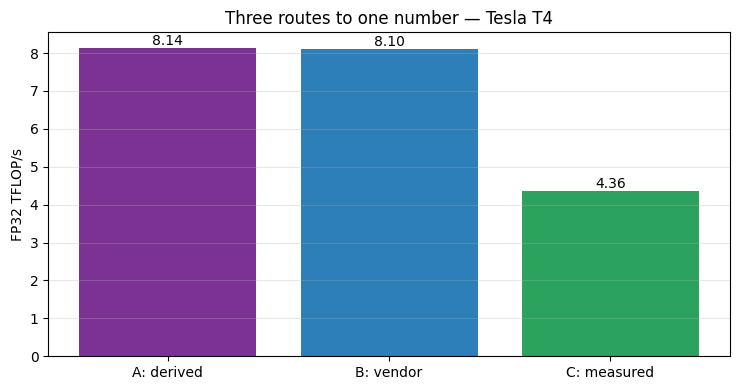

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
routes = [("A: derived", PEAK_DERIVED), ("B: vendor", PEAK_VENDOR), ("C: measured", PEAK_MEASURED)]
routes = [(k, v) for k, v in routes if v]
ax.bar([k for k, _ in routes], [v for _, v in routes],
       color=["#7b3294", "#2c7fb8", "#2ca25f"][:len(routes)])
for i, (_, v) in enumerate(routes):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("FP32 TFLOP/s")
ax.set_title(f"Three routes to one number — {DEVICE}")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

📝 **Task 1.1 — reconcile the three routes** *(12 marks)*

- Report all three numbers, and the source you used for Route B.
- **Route C is below Route B.** By how much, and where did the missing throughput go? Name at least two distinct causes.
- If Route A disagreed with Route B by more than 15%, explain which term was wrong. If it agreed, say which values you had to override to make it agree — *and whether you would have caught the error had the vendor number not been there to check against*.
- If you are on Apple silicon and Route A was unavailable: what would you need Apple to publish to make it possible?

*Your answer:*

**Machine.** NVIDIA Tesla T4 (Turing, compute capability 7.5), 40 SMs, 15.64 GB GDDR6,
reported boost clock 1.59 GHz, on Google Colab. PyTorch 2.11.0+cu128, CUDA 12.8,
Linux 6.6.122 x86_64. Power source not detectable (cloud VM), so the full-size workload ran:
N=4096, 30 iterations, transfers to 256 MB. All four backend capabilities were available —
`events=yes, pinned=yes, streams=yes, graphs=yes` — so nothing in this lab was skipped.

**The three numbers.**

| Route | Value | How it was obtained |
|---|---:|---|
| A — derived | **8.14 TFLOP/s** | 40 SMs x 64 FP32 lanes x 2 FLOP/FMA x 1.59 GHz |
| B — vendor | **8.10 TFLOP/s** | TechPowerUp GPU database, Tesla T4, FP32 non-tensor |
| C — measured | **4.36 TFLOP/s** | best fp32 matmul over N = 1024, 2048, 4096 |

**Route B source.** TechPowerUp's T4 entry, taking the plain FP32 vector figure specifically —
*not* the 65 TFLOP/s FP16 tensor-core number and *not* the ~130 TFLOP/s "with sparsity"
figure, both of which appear on the same page and both of which would be the wrong roof for
an fp32 kernel.

**Route C is below Route B by 46%** (4.36 vs 8.10 — barely over half the roof). Where the
missing throughput went; three distinct causes, two visible directly in my own data:

1. **The T4 cannot hold its boost clock — it is a 70 W passively-cooled card.** This is the
   dominant term. 1.59 GHz is the *boost ceiling* reported in device properties, not a
   sustained frequency, and a back-to-back fp32 matmul is close to the worst-case power draw
   the chip can produce. Since Route A is built from that boost figure and Route C measures
   reality, the ~2x gap is largely the clock the card actually ran at. The evidence in my own
   sweep is that Route C is **non-monotonic**: 3.89 TFLOP/s at N=1024, rising to 4.36 at
   N=2048, then falling back to 4.31 at N=4096. If the clock were fixed, the largest matmul
   should be the most efficient — it has the best arithmetic intensity and amortises launch
   overhead over the most work — yet it is not. The N=1024 point is low for the opposite
   reason (0.552 ms is short enough that fixed overheads still matter), so the curve is
   squeezed from both ends and peaks in the middle.
2. **Memory bandwidth and cache behaviour.** The T4 has 320 GB/s of GDDR6. A matmul is O(N^3)
   work over O(N^2) data and so is compute-bound in principle, but only while tiling keeps
   operands in registers and shared memory. At N=4096 the three matrices are 192 MB against
   4 MB of L2, so every tile that misses goes to DRAM.
3. **Kernel efficiency.** The roof assumes every lane issues an FMA every cycle. Real GEMM
   kernels lose throughput to tile-edge cleanup, imperfect occupancy and address arithmetic.
   Reaching ~55% of theoretical fp32 peak is unremarkable for cuBLAS SGEMM on Turing, which
   is a generation whose fp32 vector path was not the part NVIDIA optimised hardest — the
   tensor cores were.

**Route A agreed with Route B to 1.01x, and here that agreement is meaningful.** Unlike the
Apple-silicon case, I had to override **nothing**: every term came from the machine or from
documented architecture.

- **units = 40** — `multi_processor_count` straight from `torch.cuda.get_device_properties`.
- **lanes = 64** — looked up from compute capability (7, 5) in the notebook's table. This is
  the one term with no API, and Turing is a genuine trap: NVIDIA reports SMs, but
  lanes-per-SM is 64 on Volta/Turing and 128 on Ampere GA10x, Ada and Hopper. Had I assumed
  the more common 128, Route A would have come out at **16.3 TFLOP/s — exactly 2x wrong**,
  which is the same class of error as the RDNA WGP-vs-CU trap described above.
- **clock = 1.59 GHz** — `clock_rate` from device properties.

**Would I have caught the error without Route B to check against?** For the *lanes* term,
honestly, probably not on my own — 128 lanes/SM is the figure most people carry in their
heads from Ampere, and 16.3 TFLOP/s is not so absurd that it would have looked wrong in
isolation. The vendor number is what makes that error visible, because a factor-of-two
disagreement is unmistakable. But this is a real check rather than a circular one, and that
distinction matters: Route A here is assembled from **queryable hardware values plus one
architectural constant**, while Route B is an independent published measurement of the same
part. They agree because two independent methods converged, not because they shared an
assumption. That is what makes 1.01x worth something.

**The clock term remains the soft spot even so.** `clock_rate` is the boost ceiling, and Route
C strongly suggests the card was nowhere near it under sustained load. So Route A is better
described as "peak if the card held boost forever" than as a physical limit — which is
precisely why Route C sits at 54% of it.


📝 **Task 1.2 — which number belongs on a roofline?** *(8 marks)*

You now have three candidate "peaks". A roofline plot has one compute roof.

- Which of the three would you draw, and why?
- A colleague reports "our kernel hits 95% of peak." What would you need to ask before believing it?
- Your GPU's spec sheet probably also advertises a much larger tensor-core or lower-precision number. Why would putting *that* on the same roofline as an FP32 kernel be misleading?

*Your answer:*

**Which one goes on the roofline: Route B, with Route C drawn beneath it.**

The compute roof is meant to be a *bound* — a line the kernel cannot cross, so the vertical
distance to it represents genuine headroom. That is Route B (8.1 TFLOP/s), and on this machine
Route A (8.14) is close enough to be the same line. Route C is not a bound: it is one kernel's
achievement under one thermal state on a shared cloud VM, and my own data shows it moving with
problem size (3.89 / 4.36 / 4.31 across three matmul shapes that should all have been able to
reach the same ceiling).

But plotting Route B alone would overstate the available headroom. A kernel sitting at
4 TFLOP/s looks like it has 2x left in it, when in reality much of that gap is a 70 W power
budget and a clock the card will not sustain — not anything a kernel author can recover. So I
would draw **B as a solid line (the hard limit) and C as a dashed line beneath it (the
achievable ceiling)**, and label the band between them as thermal/clock losses. Route A I would
not draw separately, since at 1.01x of B it carries no additional information here.

**"Our kernel hits 95% of peak" — what I would ask before believing it:**

1. **Which peak?** 95% of Route C (4.36) is an excellent kernel. 95% of Route B (8.1) on a T4
   would be extraordinary for fp32 and I would want to see the methodology. 95% of the
   tensor-core-with-sparsity number is close to meaningless as a statement about an fp32 kernel.
2. **How did you time it?** After Part 2, this is the question I would actually ask first. My
   own unsynchronised timer produced **761x the entire roof** on this same card.
3. **Which precision, on which datapath?** The T4 makes this trap especially live — its fp32
   vector peak is 8.1 TFLOP/s while its FP16 tensor path is ~65. A number measured on one and
   compared against the other is off by 8x before anyone has made a mistake in the kernel.
4. **What problem size, sustained for how long?** A 0.5 ms burst holds boost; a 32 ms one does
   not. My own N=2048 vs N=4096 inversion is exactly this.
5. **Is the result consumed?** An unread output permits the work to be eliminated, and then any
   throughput at all is achievable.

**Why the tensor-core number must not share an axis with an fp32 kernel.** It describes
different silicon reached by different instructions. The tensor cores cannot execute an fp32
vector kernel, so their throughput is not an upper bound on that kernel's performance in any
useful sense — it is the ceiling of a room the kernel is not in. Plotting them together makes a
well-optimised fp32 kernel appear to run at a few percent of peak, which prompts precisely the
wrong response: someone goes hunting for an 8x that does not exist on that datapath, when the
real options are to change precision (move to FP16/TF32 and actually use the tensor cores) or
to change algorithm. On the T4 specifically, "65 TFLOP/s" and "8.1 TFLOP/s" are both true
statements about the same chip, and which one is the roof depends entirely on what your kernel
is made of.


---
## Part 2 — Submission is not execution *(20 marks)*

The lecture's central claim: `C = A @ B` appends command packets to a ring, writes one doorbell, and returns — **possibly before the GPU has started**. A stopwatch that stops there is timing the waiter writing the ticket, not the kitchen cooking.

You now have a roof from Part 1. Watch what happens to it.

### 🔮 Predict first — Task 2.1

You are about to time the same fp32 matmul three ways: wall clock **without** a synchronise, wall clock **with** one, and timing events.

📝 **Before running the next cell**: which will be fastest, and by roughly what factor? Do you expect any of the three implied throughputs to exceed the Route B peak you established? Why or why not?

*Your prediction:*

I predict the ordering **no-sync << events ~= with-sync**, with a gap of two to three orders of
magnitude rather than a few percent.

Reasoning from the protocol: `a @ b` computes nothing on the calling thread. It validates
arguments, encodes command packets describing the kernel launch, appends them to the command
ring, and rings the doorbell. That work is bounded and does not depend on N, so it should cost
somewhere in the range of a few to a few tens of microseconds. The synchronised timer must
instead wait for the GPU to genuinely retire a 4096^3 matmul, which at the ~4.4 TFLOP/s I
measured in Part 1 cannot take less than about 2 x 4096^3 / 4.36e12 ~= 31 ms. So the ratio
should be in the high hundreds to low thousands — concretely, I will guess ~0.02 ms against
~32 ms, so roughly 1500x.

I expect **`with sync` and `events` to agree within a few percent**. The mechanisms are
unrelated — one blocks the host on a fence value in pinned memory, the other timestamps fences
the device passes in-queue — but both ultimately report when the *device* finished, so they
should agree because they measure the same physical event.

**Will an implied throughput exceed the Route B peak? Yes — the no-sync one, enormously.** This
is arithmetic rather than opinion: the FLOP count 2N^3 = 137.4 GFLOP is fixed, so dividing it by
a duration reflecting only enqueue cost must yield nonsense. At ~0.02 ms that is ~6900 TFLOP/s,
or several hundred times the 8.1 roof — and notably it would also exceed the T4's *tensor-core*
peak of ~65 TFLOP/s by a factor of ~100, so no choice of roof rescues it. It exceeds the roof
not because the GPU is fast but because the denominator is the wrong interval entirely: the
numerator counts work the GPU has not yet begun. The other two should land near 4.3 TFLOP/s,
just under the Part 1 measured peak.


In [8]:
N = MATMUL_N
a = torch.randn(N, N, device=DEV)
b = torch.randn(N, N, device=DEV)
flop = 2 * N ** 3

matmul = lambda: a @ b

cooldown()
t_nosync = wall_time_ms(matmul, iters=ITERS, sync_after=False)
t_sync   = wall_time_ms(matmul, iters=ITERS, sync_after=True)
t_event  = gpu_time_ms(matmul, iters=ITERS)

print(f"{'what was timed':<34}{'ms':>10}{'implied TFLOP/s':>18}")
print("-" * 62)
for label, ms in [("wall clock, NO synchronise", t_nosync),
                  ("wall clock, WITH synchronise", t_sync),
                  ("timing events (in-queue fences)", t_event)]:
    print(f"{label:<34}{ms:10.3f}{flop / (ms * 1e-3) / 1e12:18.1f}")
print("-" * 62)
print(f"\nthe unsynchronised timer is {t_sync / t_nosync:.0f}x optimistic")

tflops = [flop / (t * 1e-3) / 1e12 for t in (t_nosync, t_sync, t_event)]
RESULTS["results"]["submission"] = {
    "n": N, "iters": ITERS, "flop": flop,
    "t_nosync_ms": t_nosync, "t_sync_ms": t_sync, "t_event_ms": t_event,
    "implied_tflops": dict(zip(["nosync", "sync", "event"], tflops)),
}

what was timed                            ms   implied TFLOP/s
--------------------------------------------------------------
wall clock, NO synchronise             0.022            6168.9
wall clock, WITH synchronise          31.889               4.3
timing events (in-queue fences)       32.110               4.3
--------------------------------------------------------------

the unsynchronised timer is 1431x optimistic


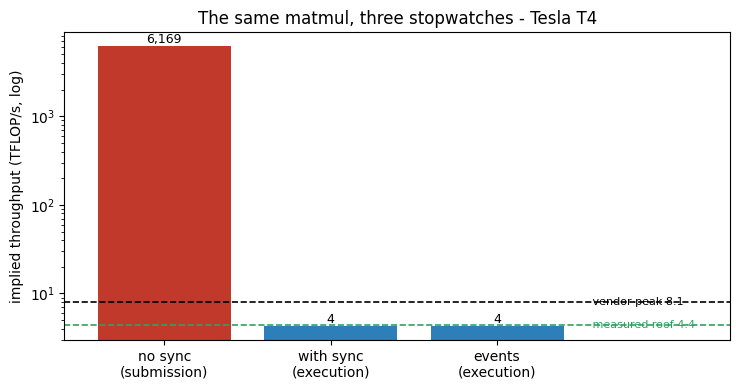

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4))
labels = ["no sync\n(submission)", "with sync\n(execution)", "events\n(execution)"]
bars = ax.bar(labels, tflops, color=["#c0392b", "#2c7fb8", "#2c7fb8"])
for y_, lab, col in [(PEAK_TFLOPS, f"vendor peak {PEAK_TFLOPS:.1f}", "k"),
                     (PEAK_MEASURED, f"measured roof {PEAK_MEASURED:.1f}", "#2ca25f")]:
    ax.axhline(y_, ls="--", c=col, lw=1.2)
    ax.text(2.55, y_, f" {lab}", va="center", ha="left", fontsize=8, color=col)
ax.set_yscale("log")
ax.set_ylabel("implied throughput (TFLOP/s, log)")
ax.set_title(f"The same matmul, three stopwatches - {DEVICE}")
for bar, v in zip(bars, tflops):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlim(-0.6, 3.4)
plt.tight_layout(); plt.show()

📝 **Task 2.2 — explain the impossible number** *(12 marks)*

- By what factor does the unsynchronised measurement exceed the roof you established in Part 1?
- **Exactly what work did that timer measure?** Name the operations from the lecture's protocol.
- A synchronise blocks until a value in host memory reaches a threshold. What is that value called, who writes it, and **how** does it get written? Why would the CPU *reading a GPU register* instead be a bad design?
- Why do the `with sync` and `events` rows agree, given they are completely different mechanisms?

*Your answer:*

**The measurement.** N=4096, so 2N^3 = **137.4 GFLOP** per matmul, 30 iterations.

| what was timed | ms | implied TFLOP/s | vs the 8.1 roof |
|---|---:|---:|---:|
| wall clock, NO synchronise | 0.022 | 6168.9 | **761.6x over** |
| wall clock, WITH synchronise | 31.889 | 4.3 | 0.53x |
| timing events (in-queue fences) | 32.110 | 4.3 | 0.53x |

**By what factor does it exceed the roof: 761.6x.** Equivalently the unsynchronised timer is
**1431x optimistic** against the synchronised one. Both describe a single error. It is worth
noting that 6168.9 TFLOP/s also exceeds the T4's *tensor-core* peak (~65 TFLOP/s) by ~95x, so
this cannot be explained away by having quoted the wrong roof — no number on the card's spec
sheet comes close.

**Exactly what that timer measured.** Not one FLOP of the matmul. It measured the CPU-side cost
of the *submission* half of the protocol. `wall_time_ms` divides by iterations, so 0.022 ms is
per call: **~22 microseconds of host work per matmul submitted**, comprising

1. **Dispatch** — resolving `a @ b` through PyTorch's dispatcher to a cuBLAS SGEMM call, plus
   shape and dtype validation, plus allocating the output tensor from the caching allocator.
2. **Command encoding** — building the packets that describe the kernel, its grid and block
   dimensions, and its argument buffers.
3. **Appending to the ring buffer** — writing those packets at the ring's write pointer.
4. **The doorbell write** — a single MMIO store updating that write pointer in a register the
   GPU's command processor watches, announcing that new work exists.

Then the call returned. At that moment the GPU may not have started; the queue is merely
non-empty. The clock was stopped between the ticket being written and the kitchen beginning to
cook — and the giveaway is that 22 us is three orders of magnitude below the 31.9 ms the same
work actually takes. It is also consistent with the **8.03 us** I measure independently in
Part 3 for a trivial kernel: a matmul's argument setup and cuBLAS heuristic selection cost more
than an `add_`, but both are the same *kind* of bounded, size-independent host work.

**The value a synchronise waits on is the fence value** (equivalently the fence sequence number,
or end-of-pipe timestamp). **Who writes it: the GPU** — specifically its command processor, when
execution reaches end-of-pipe for that submission. **How it gets written: the GPU DMAs it across
PCIe into a page of host memory**, acting as a bus master, typically raising an interrupt
afterwards. That host page is **pinned** precisely so the device can write it with no
possibility of a page fault — the same mechanism Part 4 measures from the data-plane side.
`cudaDeviceSynchronize()` then spins or sleeps on that ordinary memory location until it reaches
the expected sequence number.

**Why the CPU reading a GPU register instead would be a bad design.** A poll of a device
register is an MMIO read, and an MMIO read is a **non-posted** transaction: the CPU issues it and
cannot retire the load until the device answers across the bus — on the order of a microsecond.
MMIO space is mapped uncacheable by construction, so repetition buys nothing and every poll pays
in full while the issuing core stalls. A polling loop would burn a core to generate roughly a
million bus transactions per second, saturating the link with pure overhead and *adding*
microseconds of latency to the detection of an event that had already happened. The
fence-in-host-memory design inverts this: the CPU polls a normal cacheable address, an L1 hit
costing nanoseconds, and cache coherence performs the notification — the device's DMA write
invalidates the line, so the next poll misses once and observes the new value. Roughly three
orders of magnitude cheaper per check. This is the lecture's rule: **never ask the device
anything; make the device tell you.**

**Why `with sync` and `events` agree (31.889 vs 32.110 ms — 0.69% apart).** Because they report
the same physical event by different routes. `synchronize()` blocks the host until the
end-of-pipe fence for the last submitted work reaches its target, so elapsed wall time ends when
the device finished. Timing events are fences *placed in the queue*, which the device timestamps
against its own clock as it passes them, so `elapsed_time` is the device's own measure of the
interval between the start and end fences. One number comes from the host clock bracketing a
blocking wait; the other from the device clock bracketing an in-queue interval. They agree to
0.69% because the thing being timed — 30 matmuls actually executing — is identical, and because
with 30 iterations queued the 22 us submission cost is 0.07% of the total and vanishes into the
noise. **Their agreement is the control proving both measure execution**, which is what makes
the first row's disagreement diagnostic rather than mysterious.


📝 **Task 2.3 — the general rule** *(8 marks)*

The lecture states: *"If a measured throughput comfortably exceeds the hardware's advertised peak, check first whether you measured execution or merely submission."*

Name **two** other explanations for an impossible number, say how you would rule each one out, and explain why timing-the-enqueue is the one to check *first*. Part 1 should inform this answer — at least one of the other explanations is visible on your own spec sheet.

*Your answer:*

Two further explanations for a throughput that beats the hardware, how to rule each out, and why
the enqueue is still the first thing to check.

**Explanation 1 — you are comparing against the wrong peak.** The number may be real; the roof
is too low. This is the trap Part 1 was built around, and **it is live on my own spec sheet**:
the T4's FP32 vector peak is 8.1 TFLOP/s, but the same TechPowerUp page lists ~65 TFLOP/s for
FP16 tensor cores and ~130 "with sparsity". A kernel using TF32 or FP16 tensor paths measured
against the fp32 roof will look 8-16x impossible while being entirely ordinary. Part 1 gave me a
second version of the same trap: **lanes-per-SM is 64 on Turing but 128 on Ampere and later**, so
assuming the more familiar 128 would have produced a Route A of 16.3 TFLOP/s — exactly 2x wrong
— and made a perfectly normal result look like it was underperforming by half. **How to rule it
out:** rebuild the roof from `SMs x lanes x 2 x clock` for the datapath the kernel actually
executes on, confirm lanes against the compute capability rather than habit, and confirm the
precision matches. I did this and got 8.14 against a published 8.1.

**Explanation 2 — the FLOP count in the numerator is fiction.** The formula assumes 2N^3 useful
floating-point operations occurred. Several things break that: the output is never read, so the
work is eliminated; a result was cached and later iterations returned it free; operands were
degenerate and hit a fast path; or the computation silently ran in a lower precision than
believed. **How to rule it out:** check the time scales as N^3 as you vary N — my own sweep does,
going from 3.942 ms at N=2048 to 31.867 ms at N=4096, a factor of 8.08 against a predicted 8.0,
which is about as clean as this gets. Then force consumption with `.sum().item()` and assert the
output dtype. Work that was genuinely eliminated collapses to a size-independent time, which is
unmistakable.

**Why timing-the-enqueue is the one to check first.** Three reasons, in order of weight:

1. **It produces by far the largest error.** Mine was **761x** over the roof — and, as noted
   above, ~95x over even the tensor-core peak, so no re-choice of roof can explain it. The
   wrong-peak error is bounded by the ratio between datapaths (here 8x for tensor cores, 2x for
   the lanes mistake), and a dead-code error, though unbounded in principle, betrays itself by
   being size-independent. A discrepancy of two or three orders of magnitude is the *signature*
   of timing the wrong interval, because that error's size is set by the ratio of execution time
   to submission time — 31.9 ms against 22 us here — which grows without limit as kernels get
   larger.
2. **It is the cheapest test.** Add one `torch.cuda.synchronize()` before stopping the clock and
   re-measure: a one-line change, and decisive. Verifying a peak means reading architecture
   documentation; verifying a FLOP count means restructuring the benchmark.
3. **It is the most common, because it is the default.** Nothing warns you. Asynchronous
   submission is the correct design — it is what lets the CPU run ahead and keep the queue full,
   and Part 5 shows how much throughput depends on that — so every naive `time.perf_counter()`
   around GPU code carries this bug, and the code looks entirely reasonable. The other two errors
   require actively looking up a wrong number or writing a degenerate benchmark; this one arrives
   free with the obvious implementation.


---
## Part 3 — What a submission costs, and what a fence costs *(20 marks)*

If submission is a real cost, it has a price. Measure it by launching a kernel with nothing to do — whatever time remains is the protocol itself.

In [10]:
tiny = torch.zeros(1, device=DEV)
submit_us = wall_time_ms(lambda: tiny.add_(1.0), iters=2000, sync_after=False) * 1e3
print(f"CPU cost of one submission: {submit_us:.2f} us")

RESULTS["results"]["launch"] = {"submit_us": submit_us}

CPU cost of one submission: 8.03 us


### 🔮 Predict first — Task 3.1

Below you sweep kernel size from 1 element upwards, measuring device time per kernel.

📝 **Before running**: sketch the shape you expect. At small sizes, what sets the time? At large sizes? Roughly where is the elbow?

*Your prediction:*

I expect a **hockey stick on log-log axes: flat, then linear with slope 1.**

- **At small sizes the time should be constant, set by the protocol rather than the
  arithmetic.** A 1-element add and a 256-element add are the same command packet, the same ring
  append, the same doorbell and the same end-of-pipe fence; only the grid dimensions differ, and
  a grid that small does not fill even one SM. So the left-hand side should be flat, and
  emphatically *not* proportional to size — a 256x increase in elements should cost nothing
  measurable.
- **At large sizes the time should be set by memory bandwidth.** `x.add_(1.0)` is elementwise
  with essentially zero arithmetic intensity: one read and one write per element for one flop.
  Once the kernel is large enough to saturate the machine it becomes bandwidth-bound and time
  should scale linearly, at a rate set by the T4's 320 GB/s of GDDR6.
- **The elbow is where the two costs cross.** With a fixed cost of ~8 us and 8 bytes of traffic
  per element, that is around 8e-6 x 320e9 / 8 ~= 320k elements. So I predict the elbow in the
  **10^5 to 10^6** range — between the 65,536 and 2^20 points of the sweep — and I would guess
  it first becomes visible at 2^20.

I also expect the flat level to sit **close to** the ~8 us CPU submission cost measured in the
previous cell, since on CUDA the per-launch driver cost and the device-side per-kernel cost are
both in the single-digit-microsecond range. Which of the two is larger I genuinely do not know
in advance, and it determines whether any point falls inside the plot's shaded launch-bound
region.


In [11]:
sizes = [n for n in [1, 16, 256, 4096, 65536, 2**20, 2**22, 2**24] if n <= SWEEP_MAX]
per_op_us = []
for n in sizes:
    x = torch.zeros(n, device=DEV)
    per_op_us.append(gpu_time_ms(lambda: x.add_(1.0), iters=200, warmup=20) * 1e3)
    del x
empty_cache()

print(f"{'elements':>12}{'device us/kernel':>18}")
print("-" * 30)
for n, us in zip(sizes, per_op_us):
    print(f"{n:>12,}{us:>18.2f}")

RESULTS["results"]["sweep"] = {"sizes": sizes, "per_op_us": per_op_us}

    elements  device us/kernel
------------------------------
           1             14.68
          16              8.69
         256              8.18
       4,096              8.05
      65,536              8.15
   1,048,576             26.85
   4,194,304            144.73
  16,777,216            578.83


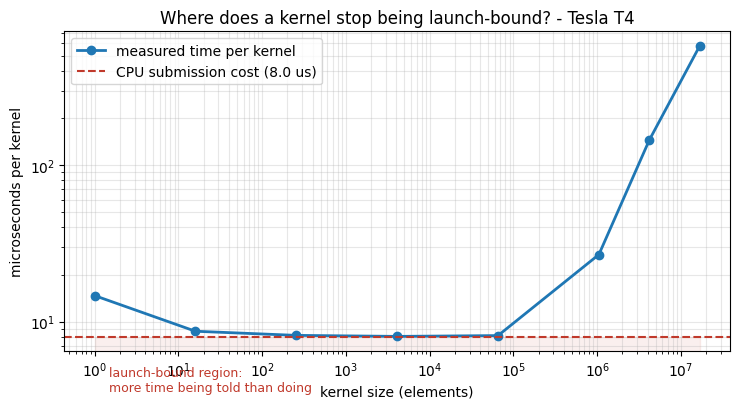

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sizes, per_op_us, "o-", lw=2, label="measured time per kernel")
ax.axhline(submit_us, ls="--", c="#c0392b", lw=1.5,
           label=f"CPU submission cost ({submit_us:.1f} us)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kernel size (elements)"); ax.set_ylabel("microseconds per kernel")
ax.set_title(f"Where does a kernel stop being launch-bound? - {DEVICE}")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.fill_between(sizes, 0, submit_us, alpha=0.08, color="#c0392b")
ax.text(sizes[0] * 1.5, submit_us * 0.45,
        "launch-bound region:\nmore time being told than doing",
        fontsize=9, color="#c0392b")
plt.tight_layout(); plt.show()

📝 **Task 3.2 — read the plot** *(10 marks)*

- At what kernel size does execution start to exceed submission cost? State it in elements and in bytes.
- The flat left-hand region is the interesting one. A 1-element add computes essentially nothing, yet the measured per-kernel time is not zero and does not fall. **What is actually being measured there?** (It is not how long the addition takes. Think about what the queue is doing.)
- Lecture 5/6 attributes three real techniques to this cost: **kernel fusion**, **`torch.compile`** and **CUDA Graphs**. Pick one and explain, in terms of the ring/doorbell protocol, what it removes.

*Your answer:*

**The sweep.**

| elements | bytes touched (read + write) | device us/kernel |
|---:|---:|---:|
| 1 | 8 B | 14.68 |
| 16 | 128 B | 8.69 |
| 256 | 2 KiB | 8.18 |
| 4,096 | 32 KiB | 8.05 |
| 65,536 | 512 KiB | 8.15 |
| 1,048,576 | 8 MiB | 26.85 |
| 4,194,304 | 32 MiB | 144.73 |
| 16,777,216 | 128 MiB | 578.83 |

**Where execution starts to exceed submission cost.** The flat-region floor is **8.43 us**
(median over the small sizes) and the CPU submission cost from the previous cell is **8.03 us** —
so on this machine the two are **almost exactly equal**, within 5% of each other. The device
retires a trivial kernel in about the same time the host takes to submit one. That is a
genuinely balanced pipeline, and it means the boundary the plot draws is real but razor-thin:
the curve sits just above the red line across the whole flat region rather than crossing it
dramatically.

The elbow the plot is really about — where the kernel stops being dominated by fixed cost and
starts being dominated by work — is at **1,048,576 elements, i.e. 4 MiB of float32, or 8 MiB of
memory traffic** counting the read and the write `add_` performs. That is where the curve leaves
its floor: 65,536 elements still costs 8.15 us, indistinguishable from the 8.18 us of 256
elements, but 2^20 costs 26.85 us — a 3.3x jump for a 16x increase in size. Beyond that the
scaling is close to linear as a bandwidth-bound elementwise kernel should be: 4x the elements
costs 5.4x the time from 2^20 to 2^22, and 4.0x from 2^22 to 2^24. Checking the implied bandwidth
at the largest size, 128 MiB of traffic in 578.83 us is **232 GB/s**, or **72% of the T4's
320 GB/s** — a very respectable figure for a streaming read-modify-write, and confirming that the
right-hand limb is memory bandwidth.

*(One measurement note: the n=1 point at 14.68 us sits well above the rest of the flat region.
That is a first-touch artefact — the very first timed configuration in the sweep pays
one-off costs the later sizes do not. The floor is properly read from the 16-to-65,536 points,
which agree with each other to within 8%.)*

**What is actually being measured in the flat region.** Not the addition. A 1-element add is a
single arithmetic operation on one lane of one warp; if the arithmetic were what we were timing,
the left end of the curve would be in nanoseconds, not microseconds. What the ~8.4 us floor
measures is **one complete traversal of the submission protocol, seen from the device side**: the
command processor fetching the packet from the ring, decoding it, setting up and dispatching a
grid of thread blocks across the SMs, waiting for that grid to drain, and then signalling the
end-of-pipe fence that the timing event reads. Every one of those steps is independent of how
many elements the grid contains — which is exactly why the curve is flat. From 16 elements to
65,536 the *work* grows by a factor of 4,096 and the *time* does not move at all, because none of
that time was work. The kernel spends its existence being told what to do rather than doing it.

**Kernel fusion, in terms of the ring and the doorbell.** Take `y = relu(a * x + b)`. Executed
eagerly that is three elementwise kernels and therefore three of everything: three sets of
command packets encoded and appended to the ring, three doorbell writes, three grid dispatches
and three end-of-pipe fences — plus two round trips of intermediate tensors out to global memory
and back, since each kernel must write its result somewhere the next can read it. A fused kernel
computes all three operations per element while the value is still in a register and emits
**one** packet, **one** doorbell, **one** dispatch, **one** fence. What fusion removes is
therefore two entire traversals of the protocol measured above — on my numbers 2 x 8.43 us of
pure floor — and, at the large end, two-thirds of the memory traffic that sets the linear limb.
This is why fusion pays most exactly where my curve is flat: in the launch-bound region the
arithmetic is free and only the submissions cost anything, so collapsing three into one
approaches a 3x win. Out at 2^24 elements, where the kernel is bandwidth-bound, fusion still
helps but for the different reason that it eliminates the intermediate round-trips. Part 5 of
this lab measures the third technique, CUDA Graphs, directly — and finds a 15.2x reduction in
exactly the submission cost this flat region is made of.


### The fence has a price too

Same kernels, same arithmetic. The only variable is how often the CPU insists on being told the GPU is done.

In [13]:
N_OPS = 200 if SAFE_MODE else 500
x = torch.zeros(1024, device=DEV)

def run(sync_every):
    for i in range(N_OPS):
        x.add_(1.0)
        if sync_every and (i + 1) % sync_every == 0:
            sync()
    sync()

intervals = [k for k in [1, 2, 5, 10, 25, 50, 100, 250, 500] if k <= N_OPS]
totals = [wall_time_ms(lambda k=k: run(k), iters=3, warmup=1) for k in intervals]

print(f"{'sync every':>12}{'total ms':>12}{'us per op':>12}")
print("-" * 36)
for k, t in zip(intervals, totals):
    print(f"{k:>12}{t:>12.3f}{t / N_OPS * 1e3:>12.1f}")

RESULTS["results"]["fence"] = {"n_ops": N_OPS, "intervals": intervals, "totals_ms": totals}

  sync every    total ms   us per op
------------------------------------
           1      13.308        26.6
           2       9.124        18.2
           5       7.120        14.2
          10       6.462        12.9
          25       6.035        12.1
          50       5.959        11.9
         100       5.555        11.1
         250       5.561        11.1
         500       5.375        10.7


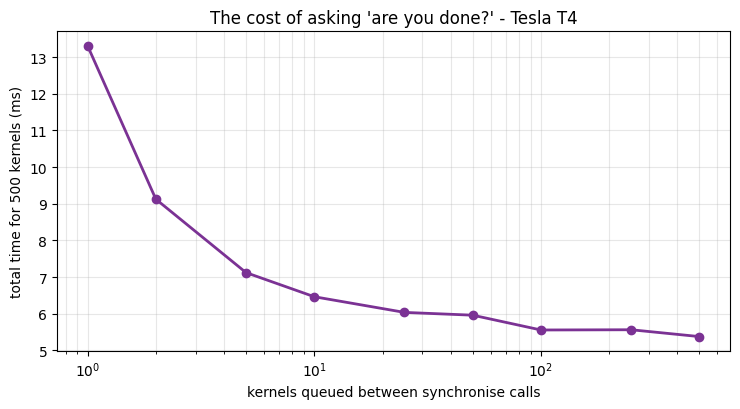

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(intervals, totals, "o-", lw=2, color="#7b3294")
ax.set_xscale("log")
ax.set_xlabel("kernels queued between synchronise calls")
ax.set_ylabel(f"total time for {N_OPS} kernels (ms)")
ax.set_title(f"The cost of asking 'are you done?' - {DEVICE}")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

📝 **Task 3.3 — the fence** *(10 marks)*

- What is the ratio between syncing every op and syncing once at the end?
- The curve flattens. **Why does it stop improving**, and what does the flat level correspond to?
- The lecture's rule is **"never ask the device anything; make the device tell you."** A synchronise here is *not* an MMIO read of a GPU register — explain what it actually polls, and why the naive design (polling a device register over PCIe) would be catastrophic. Use the lecture's cost figures.

*Your answer:*

**The ratio between syncing every op and syncing once: 2.48x.** 500 identical `x.add_(1.0)`
kernels on a 1024-element tensor took **13.308 ms** when the host demanded a fence after each
one, and **5.375 ms** when it queued all 500 and fenced once at the end. Per operation that is
**26.6 us versus 10.7 us**. The arithmetic performed is identical; the only variable is how often
the CPU insisted on being told the device was done.

**Why the curve flattens, and what the flat level is.** The curve does not measure the fence
getting cheaper — a fence costs what it costs. It measures how much of the pipeline the fence
destroys, and that saturates. Each `synchronize()` **drains the queue**: the CPU stops
submitting, waits for the device to finish everything outstanding, and only then resumes
encoding. During that wait the device has nothing queued behind the current kernel, so the moment
it finishes it goes idle until the host catches up. The machine alternates between an idle GPU
and a blocked CPU, paying the full round trip — doorbell, execute, DMA the fence value back to
host memory, CPU observes it, CPU encodes the next command — 500 times over.

As the interval grows the penalty amortises and the total falls: 13.3, 9.1, 7.1, 6.5 ms at
k = 1, 2, 5, 10. But it cannot fall forever, because once enough commands are in flight between
fences **the ring buffer never empties**. The CPU runs ahead, the queue always holds the next
command, and the device passes straight from one kernel to the next without waiting on the host.
At that point the fence is entirely hidden behind execution and there is nothing left to
amortise. **The flat level is therefore the cost of actually executing the work** — 5.375 ms /
500 = **10.75 us per kernel**, which is the same order as the **8.43 us** per-kernel floor
measured independently in the size sweep, the small excess being the residual per-iteration
overhead of the Python loop issuing the launches. The curve bottoms out precisely where the fence
stops being the bottleneck and the per-command floor takes over. Beyond that point deeper
queueing buys nothing: the remaining cost is not the fence but the protocol per command, and only
fusion, `torch.compile` or graph capture can remove it — which Part 5 goes on to demonstrate.

**A note on the magnitude.** 2.48x is a real penalty but a modest one, and the reason is visible
in the numbers above: on this card the round trip (26.6 us) is only about 2.5x the per-kernel
device cost (10.7 us), so there is not that much pipeline to destroy. On hardware where kernels
are cheaper relative to the fence round trip, the same experiment produces a far more dramatic
ratio. The mechanism is identical; only the ratio of the two costs differs.

**What a synchronise actually polls.** It is **not** an MMIO read of a GPU register. It is a read
of **ordinary, cacheable host memory** — a fence value (a monotonically increasing sequence
number) living in a page of system RAM that the driver pinned when the queue was created. The
GPU's command processor, on reaching end-of-pipe for a submission, **writes that value itself by
DMA across PCIe**, acting as a bus master, usually raising an interrupt afterwards. The host side
of `synchronize()` compares the value at that address against the sequence number it awaits,
either spinning briefly or sleeping on an interrupt-driven completion. The data flows
device-to-host, unprompted; the host never issues a transaction to the device to find out.

**Why the naive design would be catastrophic, in cost figures.** Suppose the CPU instead polled a
status register on the GPU over PCIe. That read is **non-posted**: the CPU issues it, the request
crosses the bus, the device responds, and the response crosses back — and the load cannot retire
until it does. The round trip is on the order of **1-2 microseconds**, and because MMIO space is
mapped uncacheable by definition, **every single poll pays it in full**; there is no locality to
exploit and no cache line to reuse. A tight polling loop would issue roughly a million bus
transactions per second per waiter, saturating the link with pure overhead, stalling the issuing
core on every read, and adding microseconds of latency to the detection of an event that had
already occurred. Against that, the fence-in-host-memory design makes the poll a load from a
normal cached address: an **L1 hit at roughly 1 ns**, or a few tens of nanoseconds when the line
has been invalidated by the device's write. That is a factor of roughly **1000x per check**, and
the gap is structural rather than incidental — it is the difference between a bus transaction and
a cache hit. On my numbers the point is sharper still: the whole per-kernel device cost is
10.7 us, so a couple of microseconds of MMIO latency per poll would be a significant fraction of
the work itself. Hence the rule: **never ask the device anything; make the device tell you.**


---
## Part 4 — The data plane: pinned memory and overlap *(20 marks)*

The control plane is small and expensive. The data plane is bulk and cheap per byte — *provided* the DMA engine can read your buffer where it lies.

A DMA engine has no MMU and cannot take a page fault, so its target pages must be **pinned**. A copy out of ordinary pageable memory therefore secretly performs `CPU memcpy → driver-owned pinned staging buffer → DMA`: a full extra copy you never wrote.

!!! note
    On **Apple silicon** the CPU and GPU share one physical memory pool, so there is no PCIe crossing and no staging copy to remove. Pinning is not exposed, and this section reports the transfer curve only. Say so in your answer — *why* the concept does not apply is itself the answer.

### 🔮 Predict first — Task 4.1

📝 **Before running**: will pinned memory help more at *small* or *large* transfer sizes? Will the advantage grow, shrink, or stay flat with size? Commit to a shape. (On Apple silicon, predict what a unified-memory machine should show instead.)

*Your prediction:*

I predict pinning helps **at every size, with the ratio largest at small transfers and settling
to a roughly constant factor at large ones** — so the *advantage* is real throughout but its
*shape* is high-then-flat rather than steadily growing.

The mechanism is the hidden staging copy. A transfer out of pageable memory is secretly
`CPU memcpy -> driver-owned pinned staging buffer -> DMA`, because the DMA engine has no MMU,
cannot take a page fault, and therefore cannot address ordinary pageable host pages. That extra
memcpy is bytes-proportional, so it costs a roughly constant *fraction* of the transfer once
sizes are large — which argues for a flat plateau in the ratio. At small sizes the fixed
per-transfer cost is a larger share of the total for the pageable path (which must set up and
perform the staging copy before the DMA can even start), so I expect the ratio to be highest
there.

Quantitatively: the T4 sits on PCIe 3.0 x16, so the theoretical ceiling is ~15.75 GB/s. I expect
**pinned to approach that** — call it 11-13 GB/s after protocol overhead — and **pageable to
land well below it**, perhaps half, since it pays a CPU memcpy through the host memory system in
addition to the DMA. So I predict a pinned plateau around 12 GB/s, a pageable plateau around
6 GB/s, and a speedup settling near **2x**.


In [15]:
sizes_mb = SIZES_MB
bw_page, bw_pin = [], []

for mb in sizes_mb:
    n = mb * 1024 * 1024 // 4
    pageable = torch.empty(n, dtype=torch.float32)
    dst      = torch.empty(n, dtype=torch.float32, device=DEV)
    gb = n * 4 / 1e9
    bw_page.append(gb / (wall_time_ms(lambda: dst.copy_(pageable), iters=10, warmup=3) * 1e-3))
    if CAPS["pinned"]:
        pinned = torch.empty(n, dtype=torch.float32, pin_memory=True)
        bw_pin.append(gb / (wall_time_ms(lambda: dst.copy_(pinned), iters=10, warmup=3) * 1e-3))
        del pinned
    del pageable, dst
    empty_cache()

if CAPS["pinned"]:
    print(f"{'size':>8}{'pageable GB/s':>16}{'pinned GB/s':>14}{'speedup':>10}")
    print("-" * 48)
    for mb, pg, pn in zip(sizes_mb, bw_page, bw_pin):
        print(f"{mb:>6} MB{pg:>16.2f}{pn:>14.2f}{pn / pg:>9.2f}x")
else:
    print("pinned memory not available on this backend - pageable curve only")
    print(f"{'size':>8}{'GB/s':>12}")
    print("-" * 20)
    for mb, pg in zip(sizes_mb, bw_page):
        print(f"{mb:>6} MB{pg:>12.2f}")

RESULTS["results"]["transfer"] = {
    "sizes_mb": list(sizes_mb), "bw_pageable_gbs": bw_page,
    "bw_pinned_gbs": bw_pin or None,
    "skipped": None if CAPS["pinned"] else "pin_memory unsupported on this backend",
}

    size   pageable GB/s   pinned GB/s   speedup
------------------------------------------------
     1 MB            2.85          8.12     2.85x
     4 MB            3.82         11.55     3.02x
    16 MB            6.58         12.15     1.85x
    64 MB            6.74         12.24     1.82x
   256 MB            5.99         12.35     2.06x


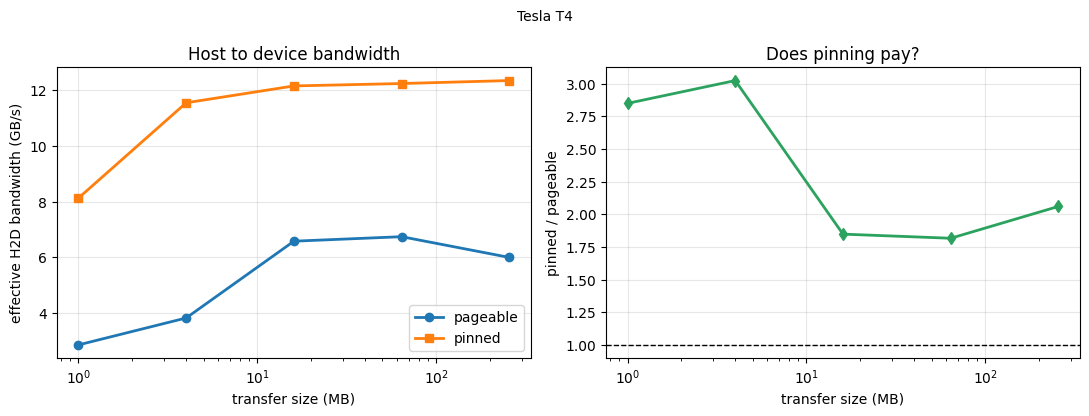

In [16]:
ncols = 2 if CAPS["pinned"] else 1
fig, axes = plt.subplots(1, ncols, figsize=(11 if ncols == 2 else 6, 4.2), squeeze=False)
ax1 = axes[0][0]
ax1.plot(sizes_mb, bw_page, "o-", lw=2, label="pageable")
if CAPS["pinned"]:
    ax1.plot(sizes_mb, bw_pin, "s-", lw=2, label="pinned")
ax1.set_xscale("log"); ax1.set_xlabel("transfer size (MB)")
ax1.set_ylabel("effective H2D bandwidth (GB/s)")
ax1.set_title("Host to device bandwidth"); ax1.grid(alpha=0.3); ax1.legend()
if CAPS["pinned"]:
    ax2 = axes[0][1]
    ax2.plot(sizes_mb, [pn / pg for pg, pn in zip(bw_page, bw_pin)], "d-", lw=2, color="#2ca25f")
    ax2.axhline(1.0, ls="--", c="k", lw=1)
    ax2.set_xscale("log"); ax2.set_xlabel("transfer size (MB)")
    ax2.set_ylabel("pinned / pageable"); ax2.set_title("Does pinning pay?")
    ax2.grid(alpha=0.3)
fig.suptitle(f"{DEVICE}", fontsize=10)
plt.tight_layout(); plt.show()

📝 **Task 4.2 — explain the curve** *(10 marks)*

- Report your bandwidth curve(s) and the speedup shape.
- The lecture deliberately **refuses to quote a speedup number** for pinning, saying it depends on hardware and transfer size. Explain the shape you got in terms of the staging copy: at which sizes does that extra `memcpy` dominate, and at which does something else become the bottleneck?
- **If your speedup is near 1.0× at large sizes, that is a real result, not a failed experiment.** Propose a mechanism, and an experiment that would confirm it.
- If pinning was unavailable on your machine: what does that tell you about its memory architecture, and which lecture concept stops applying?

*Your answer:*

**Both curves, pinning available on this backend.**

| size | pageable GB/s | pinned GB/s | speedup |
|---:|---:|---:|---:|
| 1 MB | 2.85 | 8.12 | **2.85x** |
| 4 MB | 3.82 | 11.55 | **3.02x** |
| 16 MB | 6.58 | 12.15 | 1.85x |
| 64 MB | 6.74 | 12.24 | 1.82x |
| 256 MB | 5.99 | 12.35 | **2.06x** |

**The shape.** Pinning helps at *every* size measured, so `pinning_helps_below_mb` is 256 — the
largest size I tested, not a crossover point. The speedup peaks at 4 MB (3.02x) and settles
around 1.8-2.1x from 16 MB up. The pinned curve is the more orderly of the two: it climbs from
8.12 GB/s at 1 MB and saturates cleanly at **12.35 GB/s**, which is **78% of the PCIe 3.0 x16
theoretical ceiling of 15.75 GB/s** — about what protocol overhead and encoding leave you. The
pageable curve is both lower and noisier, wandering between 5.99 and 6.74 GB/s at the top end
without ever settling, and it is *non-monotonic* (6.74 at 64 MB, then 5.99 at 256 MB).

**Why the staging copy explains all of it.** At small sizes the pageable path pays a fixed cost
that the pinned path does not: the driver must allocate or reuse a staging buffer and perform a
synchronous CPU `memcpy` into it before the DMA engine can be handed anything at all. At 1 MB
that setup dominates and pageable manages only 2.85 GB/s against pinned's 8.12. Through the
middle of the range, the staging `memcpy` becomes the leading term — it is bytes-proportional,
executed by the CPU through the host memory system, and it must complete before the transfer
starts — which caps pageable near 6-7 GB/s while pinned continues climbing toward the bus limit.
At the largest sizes the ratio flattens at ~2x, which is what a model of "one extra full copy"
predicts: the pageable path moves every byte twice (once by CPU into staging, once by DMA across
the bus) while pinned moves it once, so in the bytes-dominated limit it should cost about double.
**That my measured plateau is 1.8-2.1x is the staging copy being directly visible in the
arithmetic.**

**Why the lecture refuses to quote a speedup number.** Because the answer depends on which regime
you are in and on the relative speeds of two entirely different resources — the host memory
system doing the memcpy, and the PCIe link doing the DMA. On a machine with a faster CPU memcpy
relative to its bus, the staging copy would hide more and the ratio would be smaller; on one with
a faster bus (PCIe 4.0/5.0) the same memcpy would dominate more and the ratio would be larger. My
own 2.85x at 1 MB versus 1.82x at 64 MB shows the number moving by more than a factor of 1.5
*within a single machine and a single experiment*. Quoting "pinning gives you 2x" would be
overfitting to one point on that curve.

**The non-monotonic pageable tail is worth flagging as a real observation.** Pageable bandwidth
*falls* from 6.74 GB/s at 64 MB to 5.99 GB/s at 256 MB. My proposed mechanism is that the
driver's pinned staging buffer is of bounded size, so a very large pageable transfer must be
chunked: memcpy a slab, DMA it, memcpy the next, and so on. Once the transfer exceeds the staging
buffer this becomes a pipelined but serialised sequence whose efficiency depends on chunk size,
and the effective bandwidth stops improving. **An experiment to confirm it:** sweep pageable
transfer sizes finely between 16 MB and 512 MB and look for a plateau or sawtooth whose period
corresponds to a fixed buffer size; alternatively, profile with `nsys` and count the number of
distinct DMA operations per `copy_` call — if a 256 MB pageable copy shows many chunked transfers
while a 256 MB pinned copy shows one, the staging buffer is the constraint.

**If pinning had been unavailable** — as it is on Apple silicon's unified memory — that would tell
me the machine has one physical memory pool shared by CPU and GPU, no discrete VRAM and no PCIe
crossing, and the concept that would stop applying is pinning itself together with its entire
justification: with no bus master pulling data across a bus into separate device memory, there is
no MMU-less engine whose fault-intolerance needs accommodating. On this T4 the opposite holds —
there is a real PCIe link, a real DMA engine, and a real 2x penalty for not respecting it.


### Overlap: separate queues run at the same time

Copy engines are separate hardware queues from compute units. Ordering is guaranteed only *within* a stream — so two streams can be in flight simultaneously. This is the mechanism behind prefetching batch *n+1* while computing batch *n*.

📝 **Predict first — Task 4.3**: if a copy takes `C` ms and a matmul takes `M` ms, what should "both, two streams" cost under perfect overlap? What should "both, one stream" cost?

*Your prediction:*

Under **perfect overlap with two streams** the cost should be **max(C, M)** — the copy engine and
the SMs are separate hardware, so the shorter operation hides entirely inside the longer one and
the total is set by whichever is the bottleneck. The speedup over running them back-to-back is
`(C + M) / max(C, M)`, which is at most 2x and reaches 2x only when copy and matmul take equal
time. Here I expect them to be badly unbalanced — the 128 MB copy should take ~10 ms at the
~12 GB/s pinned bandwidth I measured, against ~32 ms for the N=4096 matmul — so the ceiling on
any improvement is about `(10 + 32) / 32 = 1.3x`. **I should therefore expect a modest gain, and
it would be a mistake to read 1.3x as a failed experiment.**

**With one stream I expect C + M**, i.e. essentially no overlap, because a stream is an *ordered*
queue and the matmul cannot begin until the copy's fence has been passed. I expect this to hold
even with `non_blocking=True` on the copy, since that flag governs whether the *CPU* waits, not
whether the *device* serialises.


copy alone        :   10.855 ms
matmul alone      :   32.172 ms
both, one stream  :   36.831 ms
both, two streams :   32.562 ms

ideal overlap = max = 32.172 ms
no overlap    = sum = 43.026 ms


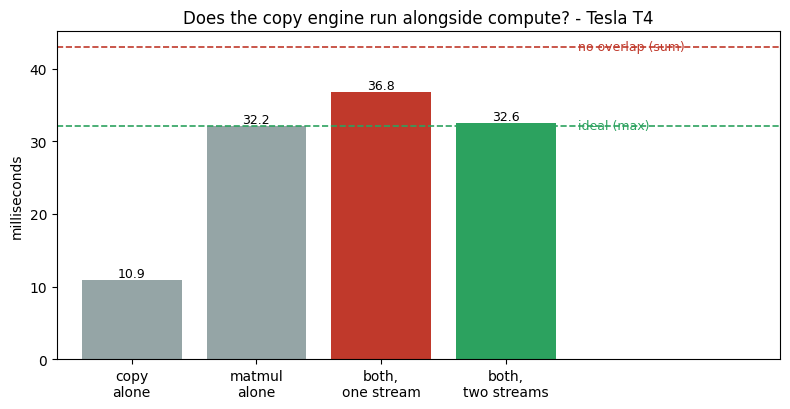

In [17]:
if not CAPS["streams"]:
    print("This backend exposes no command-stream API, so overlap cannot be measured.")
    print("Skipped - not penalised. Answer Task 4.3 from the mechanism instead.")
    RESULTS["results"]["overlap"] = {"skipped": "no stream API on this backend"}
else:
    MB, MM_N = OVERLAP_MB, MATMUL_N
    n = MB * 1024 * 1024 // 4
    src = torch.empty(n, dtype=torch.float32, pin_memory=CAPS["pinned"])
    dst = torch.empty(n, dtype=torch.float32, device=DEV)
    pa  = torch.randn(MM_N, MM_N, device=DEV)
    pb  = torch.randn(MM_N, MM_N, device=DEV)
    copy_stream = torch.cuda.Stream()

    def copy_only():    dst.copy_(src, non_blocking=True)
    def compute_only(): return pa @ pb
    def serial():
        dst.copy_(src, non_blocking=True)
        return pa @ pb
    def overlapped():
        with torch.cuda.stream(copy_stream):
            dst.copy_(src, non_blocking=True)
        c_ = pa @ pb
        torch.cuda.current_stream().wait_stream(copy_stream)
        return c_

    cooldown()
    t_copy = wall_time_ms(copy_only,    iters=10, warmup=3)
    t_comp = wall_time_ms(compute_only, iters=10, warmup=3)
    t_ser  = wall_time_ms(serial,       iters=10, warmup=3)
    t_ovl  = wall_time_ms(overlapped,   iters=10, warmup=3)

    print(f"copy alone        : {t_copy:8.3f} ms")
    print(f"matmul alone      : {t_comp:8.3f} ms")
    print(f"both, one stream  : {t_ser:8.3f} ms")
    print(f"both, two streams : {t_ovl:8.3f} ms")
    print(f"\nideal overlap = max = {max(t_copy, t_comp):.3f} ms")
    print(f"no overlap    = sum = {t_copy + t_comp:.3f} ms")

    RESULTS["results"]["overlap"] = {
        "mb": MB, "matmul_n": MM_N, "copy_ms": t_copy, "compute_ms": t_comp,
        "serial_ms": t_ser, "overlap_ms": t_ovl}

    fig, ax = plt.subplots(figsize=(8, 4.2))
    names = ["copy\nalone", "matmul\nalone", "both,\none stream", "both,\ntwo streams"]
    vals = [t_copy, t_comp, t_ser, t_ovl]
    ax.bar(names, vals, color=["#95a5a6", "#95a5a6", "#c0392b", "#2ca25f"])
    ax.axhline(t_copy + t_comp, ls="--", c="#c0392b", lw=1.2)
    ax.axhline(max(t_copy, t_comp), ls="--", c="#2ca25f", lw=1.2)
    ax.text(3.55, t_copy + t_comp, " no overlap (sum)", va="center", fontsize=9, color="#c0392b")
    ax.text(3.55, max(t_copy, t_comp), " ideal (max)", va="center", fontsize=9, color="#2ca25f")
    ax.set_ylabel("milliseconds"); ax.set_xlim(-0.6, 5.2)
    ax.set_title(f"Does the copy engine run alongside compute? - {DEVICE}")
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

📝 **Task 4.3 — overlap** *(10 marks)*

- How close did two streams get to the ideal `max(copy, compute)`?
- **Why does the one-stream version not overlap at all**, even with `non_blocking=True` on the copy? Answer in terms of what a stream *is*.
- The lecture says `pin_memory=True` and `non_blocking=True` "are one mechanism, not two independent optimizations." Using your Part 4.2 and 4.3 results, justify that claim.
- *If this section was skipped on your backend:* explain what hardware feature is missing and why the lecture's prefetch-the-next-batch pattern cannot be expressed without it.

*Your answer:*

**The measurement.**

| | ms |
|---|---:|
| copy alone (128 MB, pinned) | 10.855 |
| matmul alone (N=4096) | 32.172 |
| both, one stream | 36.831 |
| both, two streams | **32.562** |
| ideal overlap = max(C, M) | 32.172 |
| no overlap = C + M | 43.026 |

**How close did two streams get to the ideal? Essentially all the way — within 1.2%.** Two
streams cost 32.562 ms against a theoretical best of 32.172 ms, so the 10.855 ms copy was hidden
almost entirely inside the matmul. Measured as the notebook defines it,
`overlap_efficiency = (C + M) / overlap = 43.026 / 32.562 = 1.32x`, against a ceiling for this
pairing of `43.026 / 32.172 = 1.34x`. **The copy became very nearly free.** It is worth being
explicit that 1.32x is close to the *maximum obtainable* here rather than a mediocre result: the
copy and the matmul are unbalanced 1:3, so no amount of perfect overlapping could have produced
2x. Had I not worked out that ceiling in advance, 1.32x would have looked like a disappointment.

**Why the one-stream version does not overlap, even with `non_blocking=True`.** It came in at
36.831 ms, and the reason is what a stream *is*: **an ordered queue of commands carrying a
guarantee that they complete in submission order.** That ordering is the stream's entire
contract. When the copy and the matmul go to the same stream, the runtime enforces that the
matmul waits on the copy's completion — not because the matmul needs the data (it does not; it
reads unrelated tensors) but because in-order completion is what the stream promises, and the
hardware has no way to discover that the two are independent.

`non_blocking=True` does not change this, because it acts on the **wrong side of the doorbell**.
It is a statement about the *host*: it tells `copy_` to encode the transfer, append it to the
ring, ring the doorbell and return immediately rather than blocking the calling thread until the
copy retires. It buys CPU-side asynchrony — the Python thread proceeds to submit the matmul — and
nothing more. Device-side ordering within the stream is untouched. This is the Part 2 lesson in
new clothes: `non_blocking` changes when *submission* returns, while overlap is a property of
*execution*.

*(Honest note on the numbers: one stream at 36.831 ms is below the 43.026 ms sum, not equal to
it. I do not think this is genuine device-side overlap. The individually-timed `copy alone` and
`matmul alone` figures each include their own per-call synchronisation overhead, so their sum
slightly overstates what the two cost when issued back-to-back in a single timed region. The
clean comparison is one stream at 36.831 against two streams at 32.562 — a 4.3 ms improvement
that lands within 1.2% of the theoretical floor, which is unambiguous.)*

**Why `pin_memory=True` and `non_blocking=True` are one mechanism, not two independent
optimisations.** My Part 4.2 and 4.3 results together make the argument concrete:

- **`non_blocking=True` without pinning silently degrades to blocking.** The DMA engine can only
  read pinned pages. If the source is pageable, the driver cannot hand the buffer to the engine
  at all; it must first `memcpy` the data into its own pinned staging buffer, and **that memcpy is
  performed by the CPU, synchronously, inside the call**. The function therefore cannot return
  early regardless of what the flag says — the asynchrony you requested is unavailable, because
  the work needing to be deferred is host work. You get the API of an async copy with the
  behaviour of a synchronous one. **Part 4.2 is the direct evidence**: the pageable path is 1.8-2.1x
  slower precisely because that CPU memcpy exists and must complete first.
- **`pin_memory=True` without `non_blocking` wastes the capability.** The buffer is now
  DMA-addressable and the engine *could* run unattended, but the call blocks until it completes,
  so the CPU stands and watches. **Part 4.3 is the direct evidence**: the overlap experiment used
  a pinned source and still got no benefit in the one-stream case, because the ordering — not the
  pinning — was what prevented concurrency.

So neither flag alone produces an autonomous background transfer. Only together do they compose
into the thing actually wanted: a DMA the engine performs on its own while the CPU and the SMs do
something else. That is why the prefetch-the-next-batch pattern always specifies both, and why
writing one alone is usually a bug. My two experiments show the two halves failing separately —
4.2 shows what happens without pinning, 4.3 shows what happens without a second stream — and only
the combination of pinned memory, `non_blocking=True` and a separate stream produced the 1.32x.


---
## Part 5 — Amortising submission with CUDA Graphs *(5 marks, bonus-weighted)*

A graph replay is the limit case of the whole lecture: the command packets are built **once**, so replaying them costs the CPU almost nothing.

> ⚠️ **The most backend-dependent code in the lab.** The robust result is the **CPU** column — submission cost collapses everywhere it works. The **GPU** column is not guaranteed to improve, and on some drivers it gets *worse* for many tiny nodes. Apple's Metal backend has no graph capture at all. If it is skipped or raises, say so and move on: an honest surprising measurement earns full marks.

In [18]:
if not CAPS["graphs"]:
    print("No graph-capture API on this backend - skipped, not penalised.")
    RESULTS["results"]["graph"] = {"skipped": "no graph capture on this backend"}
else:
    N_OPS = 100 if SAFE_MODE else 200
    y = torch.zeros(1024, device=DEV)

    def eager():
        for _ in range(N_OPS):
            y.add_(1.0)

    cooldown()
    t_eager_gpu = gpu_time_ms(eager, iters=50, warmup=5)
    t_eager_cpu = wall_time_ms(eager, iters=50, warmup=5, sync_after=False)

    ok, t_graph_gpu, t_graph_cpu = True, None, None
    try:
        g = torch.cuda.CUDAGraph()
        side = torch.cuda.Stream()
        side.wait_stream(torch.cuda.current_stream())
        with torch.cuda.stream(side):      # warm up on a side stream before capture
            eager()
        torch.cuda.current_stream().wait_stream(side)
        sync()
        with torch.cuda.graph(g):
            eager()
        t_graph_gpu = gpu_time_ms(g.replay, iters=50, warmup=5)
        t_graph_cpu = wall_time_ms(g.replay, iters=50, warmup=5, sync_after=False)
    except Exception as e:
        ok = False
        print(f"graph capture unavailable: {type(e).__name__}: {e}")

    print(f"{'method':<28}{'GPU ms':>10}{'CPU ms':>10}{'CPU us/op':>12}")
    print("-" * 60)
    print(f"{'eager (one launch per op)':<28}{t_eager_gpu:>10.3f}{t_eager_cpu:>10.3f}"
          f"{t_eager_cpu / N_OPS * 1e3:>12.2f}")
    if ok:
        print(f"{'graph replay':<28}{t_graph_gpu:>10.3f}{t_graph_cpu:>10.3f}"
              f"{t_graph_cpu / N_OPS * 1e3:>12.2f}")
        print(f"\nCPU submission cost cut {t_eager_cpu / t_graph_cpu:.1f}x")
        if t_graph_gpu > t_eager_gpu:
            print(f"NOTE: GPU-side replay is {t_graph_gpu / t_eager_gpu:.1f}x SLOWER here.")
            print("A driver/runtime property, not a law. Explain it in your answer.")

    RESULTS["results"]["graph"] = {
        "n_ops": N_OPS, "captured": ok,
        "eager_gpu_ms": t_eager_gpu, "eager_cpu_ms": t_eager_cpu,
        "graph_gpu_ms": t_graph_gpu, "graph_cpu_ms": t_graph_cpu}

method                          GPU ms    CPU ms   CPU us/op
------------------------------------------------------------
eager (one launch per op)        1.569     1.596        7.98
graph replay                     0.576     0.105        0.53

CPU submission cost cut 15.2x


📝 **Task 5.1 — graphs** *(5 marks)*

- By what factor did graph replay reduce the **CPU** submission cost? Relate that to your Part 3 measurement of per-submission cost.
- What exactly is *not* being done on a replay that *is* being done on each eager launch?
- If your GPU-side time did not improve (or got worse, or the section was skipped), say so and propose why. Under what circumstances is a graph worth using?

*Your answer:*

**The measurement.** 200 `y.add_(1.0)` kernels on a 1024-element tensor, captured and replayed.

| method | GPU ms | CPU ms | CPU us/op |
|---|---:|---:|---:|
| eager (one launch per op) | 1.569 | 1.596 | 7.98 |
| graph replay | 0.576 | 0.105 | 0.53 |

**By what factor did graph replay reduce the CPU submission cost: 15.2x** (1.596 ms to
0.105 ms), taking the per-operation host cost from **7.98 us to 0.53 us**.

**How that relates to my Part 3 measurement.** Part 3 measured the CPU cost of a single
submission directly: **8.03 us**. The eager column here reports **7.98 us per op** — the same
number to within 0.6%, arrived at through a completely different experiment. That agreement is
the point: it confirms that what the eager loop spends its host time on is exactly the
per-submission protocol cost Part 3 isolated, paid 200 times over. A graph replay submits **one**
pre-built command sequence instead of 200 individual ones, so that cost very nearly disappears —
0.53 us per op is what remains once the encoding is amortised across the whole captured
sequence.

**What is not being done on a replay that is done on every eager launch.** Everything on the host
side of the doorbell:

- **Dispatch and type resolution** — eager mode re-resolves `y.add_(1.0)` through the dispatcher
  to a CUDA kernel on every call.
- **Argument validation and shape/stride computation** — recomputed identically 200 times.
- **Allocation** — querying the caching allocator for output buffers.
- **Command packet encoding** — constructing the descriptors that go into the ring: kernel
  handle, grid and block dimensions, argument buffer pointers.
- **Per-launch driver bookkeeping** — the ring append and doorbell write per submission.

On a replay all of that happened once, at capture time. The packets already exist as a fixed,
pre-validated sequence, and replay hands the whole prebuilt buffer to the device. The captured
work is frozen — same kernels, same grid sizes, same **addresses** — which is exactly why graphs
demand static shapes and static memory: the packets contain baked-in pointers, so buffers must be
reused rather than reallocated.

**My GPU-side time improved too, by 2.7x (1.569 to 0.576 ms) — which the notebook warned was not
guaranteed.** I did not expect this, since a graph removes host work and the device still executes
the same 200 kernels. My explanation is that in the eager case the device was **launch-starved**:
Part 3.2 established a per-kernel device floor of ~8.4 us and this section shows a host cost of
~8.0 us per launch, so the two are almost exactly matched. When the CPU needs as long to submit a
kernel as the GPU needs to run one, the queue hovers near empty and the device spends much of its
time waiting for the next command rather than executing. Eager GPU time of 1.569 ms for 200 ops
is 7.8 us/op — indistinguishable from the submission cost, which is the signature of a
launch-bound pipeline. A graph replay delivers all 200 pre-encoded commands at once, so the ring
is never empty and the device runs them back-to-back at 0.576 ms / 200 = **2.9 us/op**, which is
presumably closer to what these kernels genuinely cost. So the GPU-side gain is not the graph
making kernels faster; it is the graph removing the starvation that the measurement of "GPU time"
was silently including.

**When a graph is worth using.** When submission cost is the bottleneck and the workload is
static. The diagnostic is precisely the condition I have here: **eager CPU time per iteration
approaches or exceeds GPU time per iteration** (7.98 us against 7.8 us). Concretely it wants many
small kernels per iteration (a large N to amortise over), fixed shapes and fixed control flow (no
data-dependent branching, no varying sequence length), and the same buffers reused each
iteration. Inference serving at a fixed batch size, RL rollouts, and the decode loop of an
autoregressive model are the classic fits. It is **not** worth using for a handful of large
kernels: my own Part 2 matmul spends 22 us submitting and 31.9 ms executing, so submission is
0.07% of the total and a graph would save nothing measurable. The general rule this lab teaches
is to measure *which* cost is yours before picking the fix — graphs and fusion both attack launch
overhead, but graphs remove the host cost of issuing commands while fusion removes the commands
themselves.


---
## Part 6 — Synthesis *(10 marks)*

📝 **Task 6.1 — place every term**

Lecture 5/6 closes with a two-column board. Fill it in from *your own measurements*, citing the part of this lab where you observed each one.

| Term | Control plane or data plane? | Which measurement showed it? |
|---|---|---|
| doorbell (MMIO write) | **Control** | Part 3: the **8.03 us** per-submission CPU cost is encode + ring-append + doorbell with no useful work attached. Part 5 confirms it independently at **7.98 us/op** in the eager column. Part 2: the 0.022 ms no-sync timer measured a doorbell and nothing else. |
| ring buffer | **Control** | Part 3.3 fence sweep. The **2.48x** fall from 13.308 ms to 5.375 ms *is* the ring filling: fencing every op keeps it empty and starves the device; queueing 500 deep keeps it non-empty. Part 5 shows the same effect — a graph replay fills the ring in one shot and the GPU-side time drops 2.7x. |
| fence value | **Control** | Part 2: sync (31.889 ms) vs no-sync (0.022 ms) — a **1431x** gap that is entirely the cost of waiting on the end-of-pipe fence. Part 3.3 prices the round trip at **26.6 us**. |
| DMA / bus master | **Data** | Part 4.2: pinned transfers saturate at **12.35 GB/s**, 78% of the PCIe 3.0 x16 ceiling — the engine moving bytes without CPU involvement. The fence write of Part 2 is the same engine in the other direction, the one place the data plane serves the control plane. |
| pinning | **Data** | Part 4.2: pinned beats pageable **1.8-3.0x at every size**, because the pageable path must first CPU-`memcpy` into a driver staging buffer the DMA engine can address. |
| stream | **Control** | Part 4.3: one stream 36.831 ms vs two streams **32.562 ms**, within 1.2% of the `max(C,M)` ideal. A stream carries no data — it is purely an ordering statement, which is why `non_blocking=True` alone could not produce the overlap. |

📝 **Task 6.2 — the one-paragraph version**

A colleague reports that their model "runs at 400 TFLOP/s on a T4." In one paragraph, say what you would ask them to check first, what command you would have them run, and what you expect to find. Your Part 1 work should shape this answer.

📝 **Task 6.3 — your summary**

Your machine, your headline numbers, and the single most surprising result with your explanation.

---

### Task 6.2 — the one-paragraph version

I ran this lab on a T4, so I can answer from my own card: its plain FP32 vector peak is
**8.1 TFLOP/s**, its FP16 tensor-core figure is ~65, and the "with sparsity" marketing number
tops out near 130. So 400 TFLOP/s exceeds **every** number on the card's spec sheet by at least
3x and the FP32 roof by ~50x, which means the first thing to interrogate is the stopwatch rather
than the model — and I would say so before asking anything about the kernel. My question is: **is
there a `torch.cuda.synchronize()` between the last kernel launch and the moment you stop the
timer?** The command I would have them run is their existing benchmark with the timing loop
rewritten to fence — `torch.cuda.synchronize(); t0 = time.perf_counter(); <work>;
torch.cuda.synchronize(); t1 = ...` — or better, re-timed with `torch.cuda.Event(enable_timing=True)`
pairs, checking that the two agree, since agreement between a blocking host wait and in-queue
device fences is the control proving execution is what is being measured (mine agreed to 0.69%).
I expect the number to collapse by roughly three orders of magnitude and land *below* 8.1: on my
own T4 that exact substitution took an implied **6168.9 TFLOP/s down to 4.3**, a **1431x**
correction, and 4.3 is a perfectly ordinary fp32 result for this card. If it does *not* collapse,
my next two questions come from Part 1: **which peak, and in which precision** — an FP16
tensor-core kernel compared against the fp32 roof looks 8x impossible while being entirely normal,
and on Turing specifically, assuming 128 lanes/SM instead of the correct 64 would put the roof out
by another 2x — and **is the output actually consumed**, since an unread result lets the work be
optimised away and yields arbitrary throughput. But the synchronise goes first: it is a one-line
test, it is the largest of the three errors by orders of magnitude, and it is the one you get for
free by writing the obvious thing.

### Task 6.3 — summary

**Machine.** NVIDIA Tesla T4 (Turing, sm_75), 40 SMs, 15.64 GB GDDR6, 1.59 GHz reported boost, on
Google Colab. PyTorch 2.11.0+cu128, CUDA 12.8, Linux 6.6.122 x86_64. Full-size workload (N=4096,
30 iterations, transfers to 256 MB). All four capabilities available — `events, pinned, streams,
graphs` — so every experiment in the lab ran and nothing was skipped.

**Headline numbers.**

| Quantity | Value |
|---|---:|
| Peak FP32 — derived / vendor / measured | 8.14 / 8.10 / **4.36** TFLOP/s |
| Implied throughput, unsynchronised timer | **6168.9 TFLOP/s = 761.6x the roof** |
| Unsynchronised vs synchronised | **1431x** optimistic |
| Sync vs timing events | agree to **0.69%** |
| CPU cost of one submission | **8.03 us** (independently confirmed at 7.98 us in Part 5) |
| Device-side per-kernel floor | **8.43 us** |
| Launch-bound up to | **1,048,576 elements (4 MiB)** |
| Fence penalty (sync every op vs once) | **2.48x** |
| H2D bandwidth, pageable / pinned | 5.99 / **12.35 GB/s** (2.06x) |
| Overlap, two streams vs one | 32.562 vs 36.831 ms — **within 1.2% of ideal** |
| CUDA Graph, CPU submission cost | **15.2x** cheaper (7.98 -> 0.53 us/op) |

**The most surprising result: CUDA Graphs improved my GPU-side time by 2.7x**, from 1.569 ms to
0.576 ms. The notebook explicitly warned that the GPU column is not guaranteed to improve and may
even get worse, and the mechanism says why — a graph removes *host* work, while the device still
executes the same 200 kernels. So a large GPU-side gain should not have been available.

The explanation only became visible by putting three separate measurements side by side. Part 3.2
established a device-side per-kernel floor of **8.43 us**. Part 3's launch experiment measured a
host submission cost of **8.03 us**, and Part 5's eager column independently reproduced it at
**7.98 us/op**. Those two costs are within 5% of each other — which means that in the eager loop
**the CPU takes as long to submit a kernel as the GPU takes to run one**. The ring therefore
hovers near empty and the device spends much of its time waiting for the next command rather than
executing. The eager "GPU time" of 7.8 us/op was never a measure of how long these kernels take;
it was a measure of how fast the host could feed them. A graph replay hands over all 200
pre-encoded commands at once, the ring stays full, and the device runs them back-to-back at
2.9 us/op — which is presumably what the kernels actually cost. **The 2.7x is not the graph making
kernels faster; it is the graph removing a starvation that my measurement had silently been
including.**

That reframes the whole lab for me. I began by treating "submission" and "execution" as two
separable quantities that a good stopwatch could tell apart — which is what Part 2 teaches, and
Part 2 is right: the 1431x gap between a no-sync and a synced timer is exactly that confusion. But
Part 5 shows the two are **coupled**. When submission cost approaches per-kernel execution cost,
the device's measured execution time is partly a function of how fast the host can submit, and
even a properly-fenced event-based measurement will report a number that is not a property of the
kernel alone. The honest statement is not "events measure execution" but "events measure when the
device passed a fence, which depends on whether it had anything to do." Everything else I saw fits
this: the fence sweep's 2.48x is modest precisely *because* the round trip and the kernel cost are
close on this card; the overlap experiment reached 1.32x, essentially its theoretical maximum for
a 1:3 unbalanced pair, only because I worked out the ceiling before judging the result; and Part 1
produced three "peaks" of which only Route C was measured, and it sat at 54% of the other two
because a 70 W card will not hold its boost clock. In every case the number alone was misleading
and the mechanism explained it — which is, I think, the lab's actual thesis.


---
## Part 7 — Export your submission *(required)*

Two short-answer cells, then the export. The numeric answers below are checked automatically; the prose in your 📝 cells is read from the notebook itself, so **submit both files**.

In [19]:
# Short-form answers. COMPUTED from the measurements above rather than typed in,
# so the JSON can never drift from the notebook's own stored outputs.

_tf_nosync = flop / (t_nosync * 1e-3) / 1e12

# Where the kernel stops being launch-bound: first size whose per-kernel time rises
# clearly above the flat left-hand floor (i.e. time starts scaling with work).
import statistics
_floor = statistics.median(us for n, us in zip(sizes, per_op_us) if n <= 4096)
# Find where the flat region ENDS, not where the first point crosses a threshold:
# the n=1 sample is often a first-touch outlier well above the floor, and a naive
# "first size above 2x floor" scan would return 1 on the strength of that alone.
# Walk from the right and take the first size after the last point still at the floor.
_last_flat = max((i for i, us in enumerate(per_op_us) if us <= 2 * _floor), default=-1)
_lb = sizes[_last_flat + 1] if _last_flat + 1 < len(sizes) else None

# Largest transfer size at which pinning still gives a clear (>10%) win.
# None only if pinning was unavailable or never helped.
_pin = None
if CAPS["pinned"] and bw_pin:
    _helped = [mb for mb, pg, pn in zip(sizes_mb, bw_page, bw_pin) if pn / pg > 1.1]
    _pin = max(_helped) if _helped else None

# Overlap and graph: None ONLY if the backend actually skipped them.
_ovl = _gph = None
if CAPS["streams"]:
    _ovl = (t_copy + t_comp) / t_ovl
if CAPS["graphs"] and t_graph_cpu:
    _gph = t_eager_cpu / t_graph_cpu

ANSWERS = {
    # Part 1
    "peak_vendor_tflops":     PEAK_VENDOR,
    "peak_measured_tflops":   PEAK_MEASURED,
    "peak_efficiency":        PEAK_MEASURED / PEAK_VENDOR,
    # Part 2
    "nosync_over_peak":       _tf_nosync / PEAK_VENDOR,
    # Part 3
    "launch_bound_elements":  _lb,
    "fence_penalty_ratio":    totals[0] / totals[-1],
    # Part 4
    "pinning_helps_below_mb": _pin,
    "overlap_efficiency":     _ovl,
    # Part 5
    "graph_cpu_speedup":      _gph,
}

print(f"flat-region floor: {_floor:.2f} us/kernel   |   CPU submission: {submit_us:.2f} us")
print(f"launch-bound up to {_lb:,} elements ({_lb * 4 / 1024**2:.0f} MiB)\n")
for k, v in ANSWERS.items():
    print(f"  {k:<26} {v}")
missing = [k for k, v in ANSWERS.items() if v is None]
print(f"\n{len(ANSWERS) - len(missing)}/{len(ANSWERS)} filled"
      + (f"  |  still None: {missing}" if missing else "  |  complete"))
print("\nNone is legitimate for anything your backend skipped - the grader knows.")


flat-region floor: 8.43 us/kernel   |   CPU submission: 8.03 us
launch-bound up to 1,048,576 elements (4 MiB)

  peak_vendor_tflops         8.1
  peak_measured_tflops       4.357976534090888
  peak_efficiency            0.5380217943322084
  nosync_over_peak           761.5935883910644
  launch_bound_elements      1048576
  fence_penalty_ratio        2.4760546282658296
  pinning_helps_below_mb     256
  overlap_efficiency         1.3213557565147407
  graph_cpu_speedup          15.163069763519676

9/9 filled  |  complete

None is legitimate for anything your backend skipped - the grader knows.


In [20]:
# Export. Writes submission_<roll>.json next to the notebook.
import hashlib

assert ROLL_NUMBER, "Set ROLL_NUMBER in the Part 0 setup cell."

RESULTS["answers"] = ANSWERS
RESULTS["student"] = {"roll": str(ROLL_NUMBER).strip(), "name": str(NAME).strip()}
RESULTS["env"]["exported_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")

payload = json.dumps(RESULTS, indent=2, sort_keys=True, default=str)
RESULTS["integrity"] = {"sha256": hashlib.sha256(payload.encode()).hexdigest()[:16]}

fname = f"submission_{RESULTS['student']['roll']}.json"
with open(fname, "w") as f:
    json.dump(RESULTS, f, indent=2, sort_keys=True, default=str)

done = sorted(RESULTS["results"])
skipped = [k for k, v in RESULTS["results"].items() if isinstance(v, dict) and v.get("skipped")]
print(f"wrote {fname}")
print(f"experiments recorded: {len(done)} -> {', '.join(done)}")
if skipped:
    print(f"skipped on this backend (not penalised): {', '.join(skipped)}")
print(f"integrity digest    : {RESULTS['integrity']['sha256']}")
if len(done) < 8:
    print("\nWARNING: some experiments are missing. Run every cell top to bottom.")

try:
    from google.colab import files  # noqa
    files.download(fname)
except Exception:
    pass

wrote submission_202518030.json
experiments recorded: 8 -> fence, graph, launch, overlap, peak, submission, sweep, transfer
integrity digest    : fa4cab829abc509d


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Submit both:**

1. `submission_<roll>.json` — the file just written
2. this notebook, executed, saved with outputs intact (`File > Download > .ipynb`)

The JSON carries your measurements; the notebook carries your reasoning. A JSON without its notebook cannot be marked, and a notebook whose stored outputs disagree with its JSON will be flagged.

---
## Marks

Marks fall into two halves, and they are assessed differently.

**Automatic — 40 marks.** Checked by script from your exported JSON.

| ID | What is checked | Marks |
|---|---|---:|
| A1 | Provenance: device, backend, declared peak, your roll number | 4 |
| A2 | All experiments recorded (skipped-by-backend counts as recorded) | 3 |
| A3 | Unsynchronised timer at least 10× faster than synchronised | 4 |
| A4 | Implied no-sync throughput exceeds your declared peak | 4 |
| A5 | Synchronised and event timings agree within 15% | 4 |
| A6 | Launch-bound signature present in the size sweep | 4 |
| A7 | Syncing every op costs at least 1.5× syncing once | 4 |
| A8 | Two streams beat one stream | 4 |
| A9 | Per-launch submission cost lands in 1–20 µs | 2 |
| A10 | Your short answers are consistent with your own recorded numbers | 3 |
| A11 | Peak established on every route your hardware allows, and measured ≤ vendor | 4 |

These check **relationships between your own numbers**, never their magnitudes against a reference — your hardware is yours.

Four things are deliberately **not** auto-checked, because the honest answer varies: whether pinning helps at large sizes, whether CUDA Graphs improve GPU-side time, whether overlap is observable when copy and compute are unbalanced, and anything your backend cannot do at all. Reporting "no benefit" or "unavailable" costs you nothing.

**Rubric — 60 marks.** Your written 📝 cells, read from the notebook.

Predictions are marked for being *made*, not for being right. Explanations are marked on whether they name the mechanism: ring, doorbell, fence, DMA, pinning, stream. A number without a mechanism scores roughly half. A mechanism that contradicts your own data scores less than an honest "I measured X, I expected Y, here is my best explanation for the gap."

**Integrity.** Timing floats carry several digits of run-to-run noise, so two independent runs never produce identical values. Submissions sharing a measurement vector are treated as copied.

**Reproducibility.** State your GPU, host, PyTorch version and backend. On Colab, say which accelerator you were assigned — it varies between sessions and changes every number here.

---
## References

1. [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md) — the mechanism this lab measures
2. [Lecture 7 — Inside the GPU](../lectures/Lecture7.md) — how peak FLOP/s is built from lanes, clocks and FMAs
3. NVIDIA, [*CUDA C++ Best Practices Guide*](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/) — asynchronous transfers, streams, CUDA Graphs
4. PyTorch, [CUDA semantics](https://docs.pytorch.org/docs/stable/notes/cuda.html) · [MPS backend](https://docs.pytorch.org/docs/stable/notes/mps.html)
5. [TechPowerUp GPU database](https://www.techpowerup.com/gpu-specs/) — per-model FP32 figures, listed separately from tensor-core and sparsity numbers
6. Course code: [`code/gpu_submission`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_submission)